# INF2008 Stage 2: Predicting ED-to-Ward Waiting Times

**Group 6**

| Member | Student ID | Primary Responsibility | Sections |
|--------|------------|------------------------|----------|
| Jing Wen | 2403444 | Pipeline, Ablation, Integration | 1, 2, 6, 8 |
| Corvan | 2402844 | Feature Engineering (lag, rolling) | 3 |
| Pamela | 2401870 | Visualizations | 4 |
| Hayden | 2402425 | Alternative Models + Infectious Disease Integration | 5 |
| Jeanie | 2403263 | Business Analysis + External Factors Documentation | 7 |

**Google Colab Link:** https://colab.research.google.com/drive/1lqcWt1dMSLVg4hnLa7oh26gVzNsYyxhR?usp=sharing

**GitHub Repository:** https://github.com/Corv123/Machine-Learning-Proj

## Stage 1 Recap

**Problem:** Predict median ED-to-ward waiting time (hours) for Singapore public hospitals.

| Model | MAE (hrs) | R² |
|-------|-----------|----|
| Dummy (Mean) | 3.36 | -0.001 |
| Linear Regression | 2.44 | 0.40 |
| Decision Tree | 2.83 | -0.11 |

**Stage 2 Goals:**
- Beat Linear Regression MAE of 2.44 hours
- Implement sklearn Pipeline (prevent data leakage)
- Conduct controlled ablation studies
- Analyze failures and propose fixes
- Explore external data (infectious disease) impact

---
# SECTION 1: SETUP & DATA LOADING
---

In [97]:
# ============================================================
# CELL 1.1: Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
np.random.seed(42)

print(" Libraries imported")

 Libraries imported


In [98]:
# ============================================================
# CELL 1.2: Load Data
# ============================================================

df = pd.read_csv('combined_hospital_daily_metrics.csv')
df = df.dropna(subset=['Waiting Time', 'Attendance', 'BOR'])
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(f" Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Hospitals: {df['Hospital'].nunique()}")
df.head()

 Loaded: 9415 rows × 7 columns
Date range: 2023-01-01 to 2026-01-10
Hospitals: 9


,Date,Day,Hospital,Waiting Time,Attendance,BOR,Is_Holiday
0,2023-01-01,Sunday,AH,1.6,64,80.5,1
1,2023-01-01,Sunday,CGH,7.7,351,89.6,1
2,2023-01-01,Sunday,KTPH,2.9,286,96.4,1
3,2023-01-01,Sunday,NTFGH,7.9,252,91.1,1
4,2023-01-01,Sunday,NUH(A),2.1,257,78.3,1


In [99]:
# ============================================================
# CELL 1.3: Define Features and Target
# ============================================================

categorical_features = ['Hospital', 'Day']
numerical_features = ['Attendance', 'BOR']
binary_features = ['Is_Holiday']

X = df.drop(columns=['Waiting Time', 'Date'])
y = df['Waiting Time']

print(f"Features: {categorical_features + numerical_features + binary_features}")
print(f"Target: Waiting Time (Mean: {y.mean():.2f} hrs)")

Features: ['Hospital', 'Day', 'Attendance', 'BOR', 'Is_Holiday']
Target: Waiting Time (Mean: 5.45 hrs)


In [100]:
# ============================================================
# CELL 1.4: Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f" Test set used ONLY ONCE in Section 7!")

 Train: 7532 | Test: 1883
 Test set used ONLY ONCE in Section 7!


In [101]:
# ============================================================
# CELL 1.5: CV Setup
# ============================================================

cv = KFold(n_splits=5, shuffle=True, random_state=42)
print(" 5-Fold CV configured")

 5-Fold CV configured


---
# SECTION 2: PIPELINE ARCHITECTURE
---

## 2.1 Pipeline Architecture

In [102]:
# ============================================================
# CELL 2.1.1: Build Preprocessor & Pipeline Factory
# ============================================================

# Build preprocessor dynamically from available columns.
# This prevents KeyError when rerunning sections out of order
# (e.g., pipelines expecting lag columns on baseline X_train).
def build_preprocessor_for_columns(columns):
    cat_cols = [c for c in ['Hospital', 'Day'] if c in columns]
    num_cols = [c for c in columns if c not in cat_cols + ['Is_Holiday']]
    bin_cols = [c for c in ['Is_Holiday'] if c in columns]

    return ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
            ('num', StandardScaler(), num_cols),
            ('bin', 'passthrough', bin_cols)
        ],
        remainder='drop'
    )

def create_pipeline(model, X_df=None):
    if X_df is not None:
        cols = list(X_df.columns)
    elif 'X_train' in globals() and hasattr(X_train, 'columns'):
        cols = list(X_train.columns)
    else:
        cols = list(X.columns)

    preprocessor = build_preprocessor_for_columns(cols)
    return Pipeline([('preprocessor', preprocessor), ('model', model)])

print("Dynamic preprocessor factory created")
print("- Categorical: Hospital, Day (if present)")
print("- Numerical: all non-categorical non-binary columns")
print("- Binary: Is_Holiday (if present)")

Dynamic preprocessor factory created
- Categorical: Hospital, Day (if present)
- Numerical: all non-categorical non-binary columns
- Binary: Is_Holiday (if present)


---
# SECTION 3: FEATURE ENGINEERING
---

In [103]:
# ============================================================
# Cell 3.1 - Create Features
# ============================================================

# Ensure chronological order within each hospital
_df = df.copy().sort_values(['Hospital', 'Date']).reset_index(drop=True)

# --- Lagged waiting-time features (use only past values) ---
_df['Lag_1_WaitTime'] = _df.groupby('Hospital')['Waiting Time'].shift(1)

_df['Lag_3_WaitTime_Avg'] = _df.groupby('Hospital')['Waiting Time'].transform(
 lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

_df['Lag_7_WaitTime_Avg'] = _df.groupby('Hospital')['Waiting Time'].transform(
 lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)

# --- Rolling attendance (past 3 days) ---
_df['Rolling_3d_Attendance'] = _df.groupby('Hospital')['Attendance'].transform(
 lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

# --- BOR daily change (from previous day) ---
_df['BOR_Change'] = _df.groupby('Hospital')['BOR'].diff(1)

# --- Month boundary flags ---
_df['Is_Month_Start'] = _df['Date'].dt.is_month_start.astype(int)
_df['Is_Month_End'] = _df['Date'].dt.is_month_end.astype(int)

# Keep engineered dataset in a dedicated variable
# (Downstream comparison will use the intersection rows where engineered features exist.)
df_feat = _df

engineered_cols = [
 'Lag_1_WaitTime', 'Lag_3_WaitTime_Avg', 'Lag_7_WaitTime_Avg',
 'Rolling_3d_Attendance', 'BOR_Change', 'Is_Month_Start', 'Is_Month_End'
]

print(' Engineered features created')
print('New columns:', engineered_cols)
print('Preview:')
print(df_feat[['Date','Hospital','Waiting Time','Attendance','BOR','Is_Holiday'] + engineered_cols].head(10).to_string())

 Engineered features created
New columns: ['Lag_1_WaitTime', 'Lag_3_WaitTime_Avg', 'Lag_7_WaitTime_Avg', 'Rolling_3d_Attendance', 'BOR_Change', 'Is_Month_Start', 'Is_Month_End']
Preview:
        Date Hospital  Waiting Time  Attendance   BOR  Is_Holiday  Lag_1_WaitTime  Lag_3_WaitTime_Avg  Lag_7_WaitTime_Avg  Rolling_3d_Attendance  BOR_Change  Is_Month_Start  Is_Month_End
0 2023-01-01       AH           1.6          64  80.5           1             NaN                 NaN                 NaN                    NaN         NaN               1             0
1 2023-01-02       AH           2.0          61  84.8           0             1.6            1.600000            1.600000              64.000000         4.3               0             0
2 2023-01-03       AH           2.1          76  92.9           0             2.0            1.800000            1.800000              62.500000         8.1               0             0
3 2023-01-04       AH           2.5          74  91.1           0

In [104]:
# ============================================================
# Cell 3.2 - Save Dataset
# ============================================================

# Save engineered dataset for reproducibility / sharing
OUT_PATH = 'data_with_features.csv'
df_feat.to_csv(OUT_PATH, index=False)

print(f" Saved engineered dataset to: {OUT_PATH}")
print(f"Rows: {df_feat.shape[0]} | Cols: {df_feat.shape[1]}")

 Saved engineered dataset to: data_with_features.csv
Rows: 9415 | Cols: 14


Train rows (chronological): 7524 | Holdout rows: 1882
Train period: 2023-01-02 to 2025-06-15
Holdout period: 2025-06-15 to 2026-01-10
FEATURE SET COMPARISON (TRAIN-ONLY, TIME-AWARE CV)
               Feature Set  n_rows                 CV  MAE Mean  MAE Std   R² Mean   R² Std
       Full Engineered Set    7524 TimeSeriesSplit(5)  1.478813 0.314850  0.662484 0.052182
           Lag-1 Wait Time    7524 TimeSeriesSplit(5)  1.553979 0.353132  0.624256 0.073725
Rolling Attendance + BOR Δ    7524 TimeSeriesSplit(5)  2.419024 0.911543  0.103050 0.569705
    Baseline (S1+Pipeline)    7524 TimeSeriesSplit(5)  2.526578 0.979657 -0.005218 0.636169

 Best Feature Set by CV MAE: Full Engineered Set


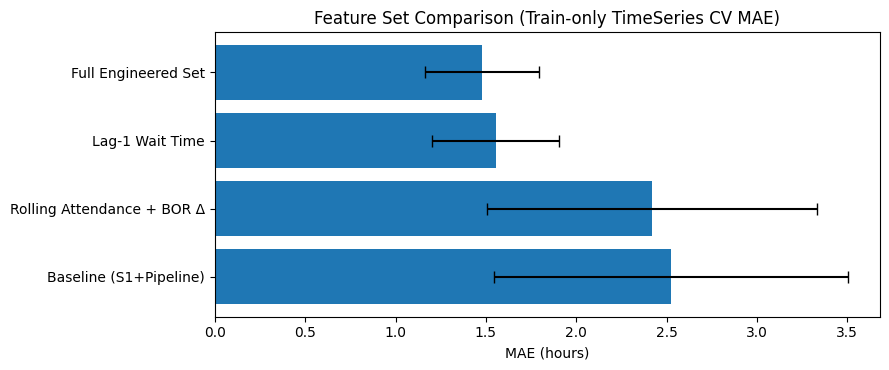

In [105]:
# ============================================================
# Cell 3.3 - Compare Feature Sets
# ============================================================

# IMPORTANT VALIDITY UPDATE:
# - Use only training-period rows (not full dataset) for model selection.
# - Use time-aware CV to reduce temporal leakage with lag/rolling features.
from sklearn.model_selection import TimeSeriesSplit

# Compare feature sets using a consistent subset where engineered features exist
required_for_compare = [
 'Lag_1_WaitTime', 'Lag_3_WaitTime_Avg', 'Lag_7_WaitTime_Avg',
 'Rolling_3d_Attendance', 'BOR_Change'
]

df_comp = df_feat.dropna(subset=required_for_compare).copy().sort_values('Date').reset_index(drop=True)

# Chronological split: earliest 80% for training-period CV, latest 20% reserved
cut_idx = int(len(df_comp) * 0.8)
df_comp_train = df_comp.iloc[:cut_idx].copy()
df_comp_holdout = df_comp.iloc[cut_idx:].copy()

print(f"Train rows (chronological): {len(df_comp_train)} | Holdout rows: {len(df_comp_holdout)}")
print(f"Train period: {df_comp_train['Date'].min().date()} to {df_comp_train['Date'].max().date()}")
print(f"Holdout period: {df_comp_holdout['Date'].min().date()} to {df_comp_holdout['Date'].max().date()}")

# Define candidate feature sets
base_cols = ['Hospital', 'Day', 'Attendance', 'BOR', 'Is_Holiday']
lag1_cols = base_cols + ['Lag_1_WaitTime']
rolling_cols = base_cols + ['Rolling_3d_Attendance', 'BOR_Change']
full_cols = base_cols + [
 'Lag_1_WaitTime', 'Lag_3_WaitTime_Avg', 'Lag_7_WaitTime_Avg',
 'Rolling_3d_Attendance', 'BOR_Change',
 'Is_Month_Start', 'Is_Month_End'
]

feature_sets = {
 'Baseline (S1+Pipeline)': base_cols,
 'Lag-1 Wait Time': lag1_cols,
 'Rolling Attendance + BOR Δ': rolling_cols,
 'Full Engineered Set': full_cols
}

# Shared evaluation model (fixed to isolate feature impact)
compare_model = RandomForestRegressor(
 n_estimators=200,
 random_state=42,
 n_jobs=-1
)

# Time-aware CV over training period only
tscv = TimeSeriesSplit(n_splits=5)

results = []
for set_name, cols in feature_sets.items():
 Xc = df_comp_train[cols]
 yc = df_comp_train['Waiting Time']

 cat_cols = [c for c in cols if c in ['Hospital', 'Day']]
 num_cols = [c for c in cols if c not in cat_cols]

 preproc = ColumnTransformer(
 transformers=[
 ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
 ('num', StandardScaler(), num_cols),
 ],
 remainder='drop'
 )

 pipe = Pipeline([('preprocessor', preproc), ('model', compare_model)])

 mae_scores = -cross_val_score(pipe, Xc, yc, cv=tscv, scoring='neg_mean_absolute_error')
 r2_scores = cross_val_score(pipe, Xc, yc, cv=tscv, scoring='r2')

 results.append({
 'Feature Set': set_name,
 'n_rows': len(df_comp_train),
 'CV': 'TimeSeriesSplit(5)',
 'MAE Mean': mae_scores.mean(),
 'MAE Std': mae_scores.std(),
 'R² Mean': r2_scores.mean(),
 'R² Std': r2_scores.std()
 })

feature_compare_df = pd.DataFrame(results).sort_values('MAE Mean')

print("="*80)
print("FEATURE SET COMPARISON (TRAIN-ONLY, TIME-AWARE CV)")
print("="*80)
print(feature_compare_df.to_string(index=False))

best_feature_set = feature_compare_df.iloc[0]['Feature Set']
print(f"\n Best Feature Set by CV MAE: {best_feature_set}")

# Simple visualization
plt.figure(figsize=(9, 3.8))
plt.barh(feature_compare_df['Feature Set'], feature_compare_df['MAE Mean'], xerr=feature_compare_df['MAE Std'], capsize=4)
plt.gca().invert_yaxis()
plt.xlabel('MAE (hours)')
plt.title('Feature Set Comparison (Train-only TimeSeries CV MAE)')
plt.tight_layout()
plt.show()

 Feature importance computed using: Full Engineered Set (train-period rows)
Top 15 features:
                   Feature  Importance
       num__Lag_1_WaitTime    0.618608
   num__Lag_7_WaitTime_Avg    0.077052
           num__Attendance    0.064337
                  num__BOR    0.043668
   num__Lag_3_WaitTime_Avg    0.039422
num__Rolling_3d_Attendance    0.037995
           num__BOR_Change    0.029624
           cat__Day_Monday    0.026142
          cat__Day_Tuesday    0.020274
         cat__Hospital_CGH    0.007315
         cat__Day_Saturday    0.006870
        cat__Day_Wednesday    0.004331
       cat__Hospital_NTFGH    0.003818
           cat__Day_Sunday    0.003101
         cat__Hospital_SKH    0.003031


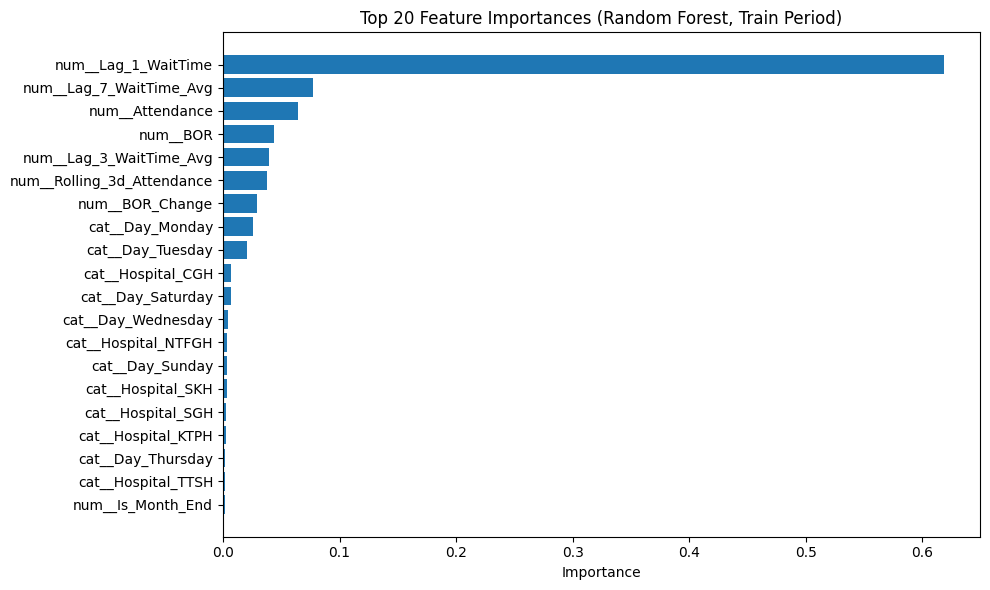

In [106]:
# ============================================================
# Cell 3.4 - Feature Importance
# ============================================================

# Fit importance model on training-period rows only
# to stay aligned with train-only model selection.

if 'best_feature_set' in globals() and best_feature_set in feature_sets:
 cols_to_use = feature_sets[best_feature_set]
 chosen_name = best_feature_set
else:
 cols_to_use = feature_sets['Full Engineered Set']
 chosen_name = 'Full Engineered Set'

# Use train subset created in Cell 3.3
X_imp = df_comp_train[cols_to_use]
y_imp = df_comp_train['Waiting Time']

cat_cols = [c for c in cols_to_use if c in ['Hospital', 'Day']]
num_cols = [c for c in cols_to_use if c not in cat_cols]

preproc_imp = ColumnTransformer(
 transformers=[
 ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
 ('num', StandardScaler(), num_cols),
 ],
 remainder='drop'
)

rf_imp = RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)
pipe_imp = Pipeline([('preprocessor', preproc_imp), ('model', rf_imp)])

pipe_imp.fit(X_imp, y_imp)

# Retrieve feature names after preprocessing
try:
 feat_names = pipe_imp.named_steps['preprocessor'].get_feature_names_out()
except Exception:
 feat_names = np.array([f'f{i}' for i in range(pipe_imp.named_steps['model'].feature_importances_.shape[0])])

importances = pipe_imp.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values('Importance', ascending=False)

print(f" Feature importance computed using: {chosen_name} (train-period rows)")
print("Top 15 features:")
print(imp_df.head(15).to_string(index=False))

# Plot top-N
TOP_N = 20
plt.figure(figsize=(10, 6))
plt.barh(imp_df.head(TOP_N)['Feature'][::-1], imp_df.head(TOP_N)['Importance'][::-1])
plt.xlabel('Importance')
plt.title(f'Top {TOP_N} Feature Importances (Random Forest, Train Period)')
plt.tight_layout()
plt.show()

**Best Feature Set:** Auto-selected in Cell 3.3 (`best_feature_set`)

**Key Findings:**
1. Temporal signals (previous-day wait time + short rolling history) can reduce MAE versus using only same-day operational metrics.
2. BOR day-to-day change and recent attendance help explain spikes that same-day BOR/attendance alone may miss.

**Recommendation:** Use the **best CV feature set** from Cell 3.3 for the champion model ablations; if results are close, prefer the **Full Engineered Set** for better failure analysis interpretability (more knobs to diagnose extreme errors).

---
# SECTION 4: VISUALIZATIONS
---

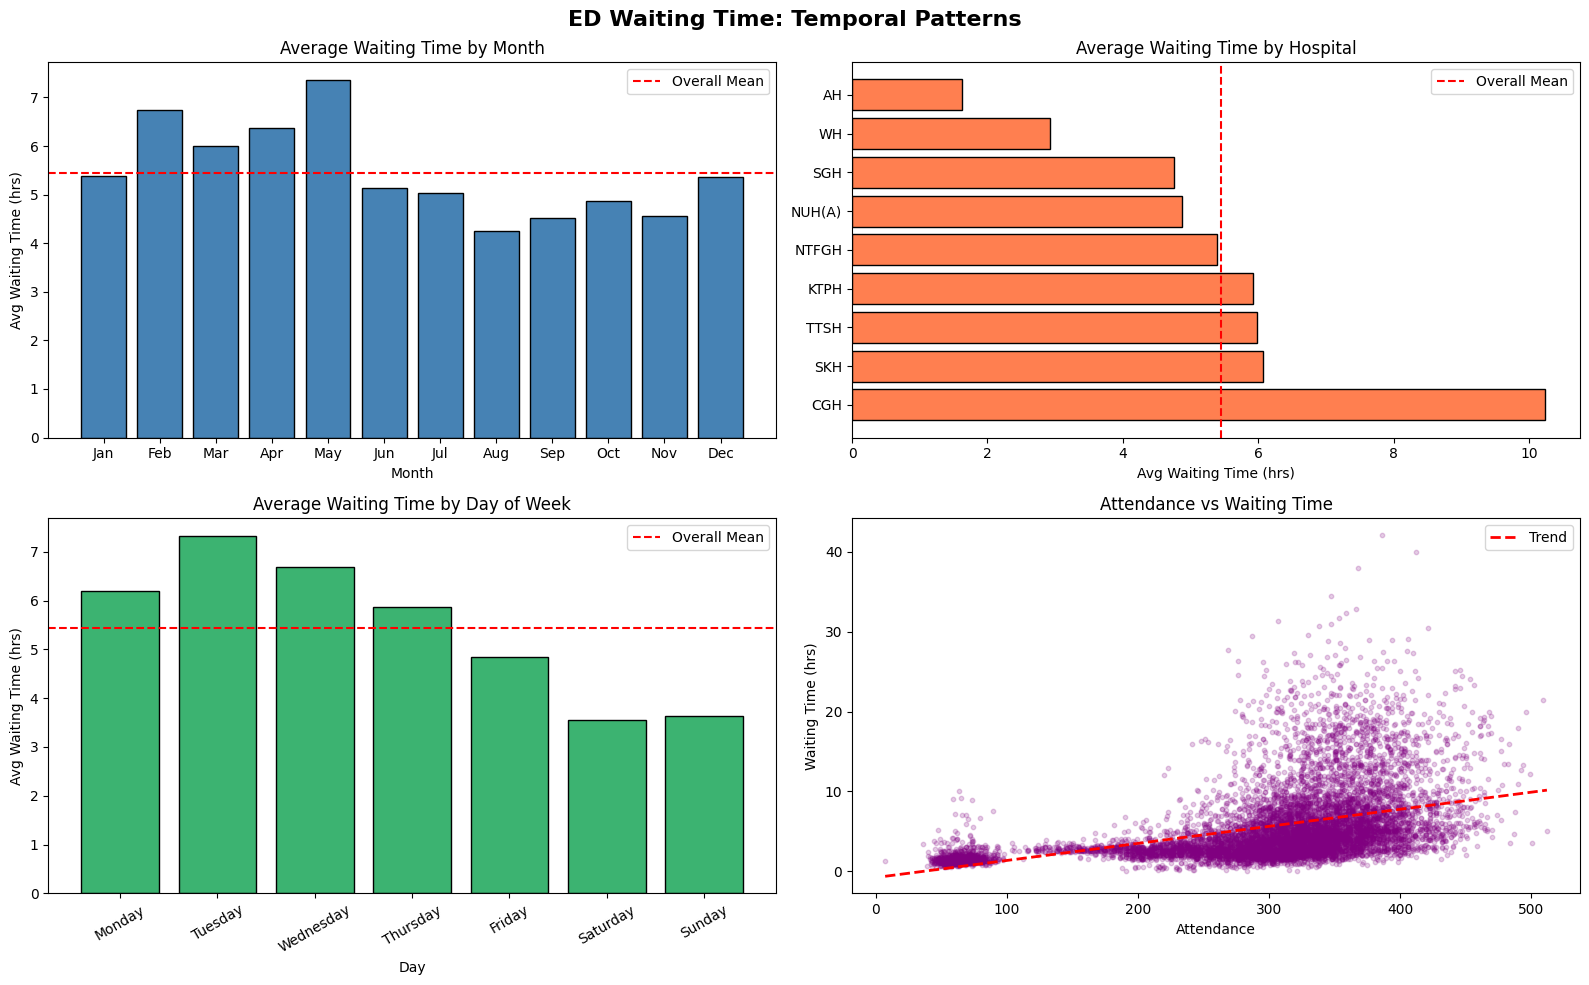

 Temporal patterns saved.


In [107]:
# ============================================================
# Cell 4.1 - Temporal Patterns (4 subplots)
# ============================================================
# TODO: Monthly, Hospital, Day-of-week, Attendance correlation

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ED Waiting Time: Temporal Patterns', fontsize=16, fontweight='bold')

# PLOT 1: MONTHLY AVERAGE WAITING TIME
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Waiting Time'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0, 0].bar(monthly_avg.index, monthly_avg.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(month_labels)
axes[0, 0].set_title('Average Waiting Time by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Avg Waiting Time (hrs)')
axes[0, 0].axhline(df['Waiting Time'].mean(), color='red', linestyle='--', label='Overall Mean')
axes[0, 0].legend()

# PLOT 2: AVERAGE WAITING TIME BY HOSPITAL
hospital_avg = df.groupby('Hospital')['Waiting Time'].mean().sort_values(ascending=False)
axes[0, 1].barh(hospital_avg.index, hospital_avg.values, color='coral', edgecolor='black')
axes[0, 1].set_title('Average Waiting Time by Hospital')
axes[0, 1].set_xlabel('Avg Waiting Time (hrs)')
axes[0, 1].axvline(df['Waiting Time'].mean(), color='red', linestyle='--', label='Overall Mean')
axes[0, 1].legend()

# PLOT 3: AVERAGE WAITING TIME BY DAY OF WEEK
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = df.groupby('Day')['Waiting Time'].mean().reindex(day_order)
axes[1, 0].bar(day_avg.index, day_avg.values, color='mediumseagreen', edgecolor='black')
axes[1, 0].set_title('Average Waiting Time by Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Avg Waiting Time (hrs)')
axes[1, 0].tick_params(axis='x', rotation=30)
axes[1, 0].axhline(df['Waiting Time'].mean(), color='red', linestyle='--', label='Overall Mean')
axes[1, 0].legend()

# PLOT 4: ATTENDANCE VS WAITING TIME SCATTER CORRELATION
axes[1, 1].scatter(df['Attendance'], df['Waiting Time'], alpha=0.2, s=10, color='purple')
axes[1, 1].set_title('Attendance vs Waiting Time')
axes[1, 1].set_xlabel('Attendance')
axes[1, 1].set_ylabel('Waiting Time (hrs)')
# Add trend line
z = np.polyfit(df['Attendance'].dropna(), df.loc[df['Attendance'].notna(), 'Waiting Time'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Attendance'].min(), df['Attendance'].max(), 100)
axes[1, 1].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Temporal patterns saved.")

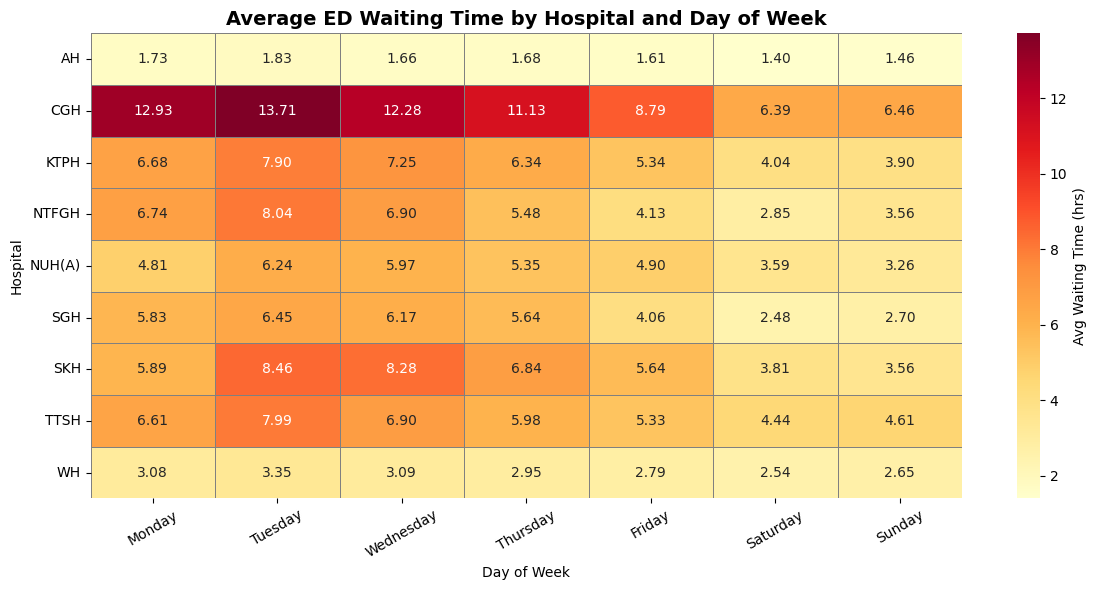

 Heatmap saved.


In [108]:
# ============================================================
# Cell 4.2 - Hospital x Day Heatmap
# ============================================================
# TODO: Use seaborn heatmap

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.groupby(['Hospital', 'Day'])['Waiting Time'].mean().unstack('Day')
heatmap_data = heatmap_data.reindex(columns=day_order)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
 heatmap_data,
 annot=True,
 fmt='.2f',
 cmap='YlOrRd',
 linewidths=0.5,
 linecolor='grey',
 ax=ax,
 cbar_kws={'label': 'Avg Waiting Time (hrs)'}
)
ax.set_title('Average ED Waiting Time by Hospital and Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hospital')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('heatmap_hospital_day.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Heatmap saved.")

In [109]:
# ============================================================
# Cell 4.3 - Identify Outlier Days
# ============================================================
# Find extreme waiting times at INDIVIDUAL hospital level

# Top 20 worst hospital-day records
top20_worst = df.nlargest(20, 'Waiting Time')[['Date', 'Hospital', 'Day', 'Waiting Time', 'Attendance', 'BOR']].reset_index(drop=True)
top20_worst['Rank'] = top20_worst.index + 1

print("=" * 80)
print("TOP 20 WORST HOSPITAL-DAY RECORDS BY WAITING TIME")
print("=" * 80)
print(f"{'Rank':<5} {'Date':<12} {'Hospital':<8} {'Day':<10} {'Wait (hrs)':<12} {'Attend':<8} {'BOR (%)'}")
print("-" * 80)
for _, row in top20_worst.iterrows():
    print(f"{int(row['Rank']):<5} {str(row['Date'].date()):<12} {row['Hospital']:<8} {row['Day']:<10} {row['Waiting Time']:<12.1f} {row['Attendance']:<8.0f} {row['BOR']:.1f}")

# Save for research
worst_dates = top20_worst['Date'].values
print(f"\n{len(top20_worst)} worst records identified.")
print(f"\nNote: KTPH appears {(top20_worst['Hospital'] == 'KTPH').sum()} times in top 20!")

# Per-hospital top 3 outliers
print("\n" + "="*80)
print("TOP 3 OUTLIERS PER HOSPITAL")
print("="*80)

for hospital in df['Hospital'].unique():
    hospital_data = df[df['Hospital'] == hospital].nlargest(3, 'Waiting Time')
    print(f"\n{hospital}:")
    for _, row in hospital_data.iterrows():
        print(f"  {row['Date'].date()} | {row['Day']:<9} | {row['Waiting Time']:5.1f} hrs | BOR: {row['BOR']:.1f}%")

TOP 20 WORST HOSPITAL-DAY RECORDS BY WAITING TIME
Rank  Date         Hospital Day        Wait (hrs)   Attend   BOR (%)
--------------------------------------------------------------------------------
1     2023-03-13   KTPH     Monday     42.1         386      97.3
2     2023-03-27   KTPH     Monday     40.0         412      99.4
3     2023-05-08   NTFGH    Monday     38.0         368      94.4
4     2023-03-21   KTPH     Tuesday    34.5         347      98.0
5     2023-03-14   KTPH     Tuesday    32.9         366      97.9
6     2023-03-22   KTPH     Wednesday  32.3         359      96.6
7     2023-03-28   KTPH     Tuesday    31.7         353      96.3
8     2023-04-02   KTPH     Sunday     31.3         307      100.0
9     2023-05-09   NTFGH    Tuesday    31.0         347      95.0
10    2023-04-30   CGH      Sunday     30.7         338      88.9
11    2023-02-13   KTPH     Monday     30.5         421      100.0
12    2023-03-26   KTPH     Sunday     29.6         330      99.6
13    

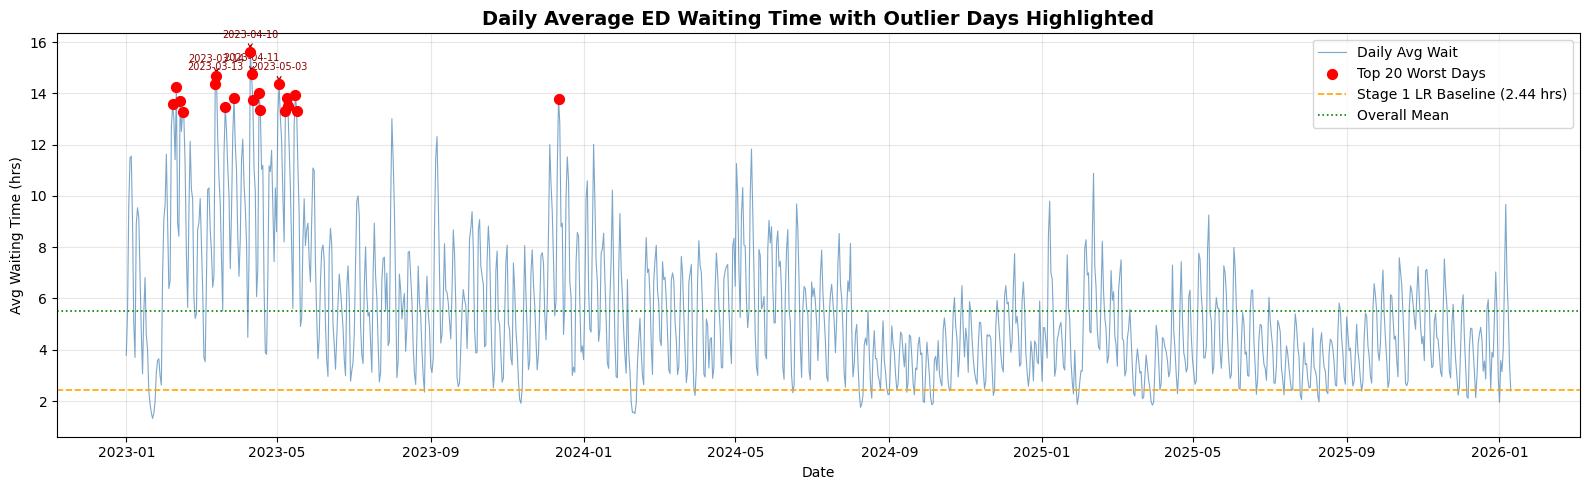

 Outlier timeline saved.


In [110]:
# ============================================================
# Cell 4.4 - Outlier Timeline
# ============================================================
# TODO: Plot daily average with worst days highlighted

# Recompute daily_avg if not already in scope
daily_avg = df.groupby('Date').agg(
 Avg_Wait=('Waiting Time', 'mean')
).reset_index()

top20_worst = daily_avg.nlargest(20, 'Avg_Wait')

fig, ax = plt.subplots(figsize=(16, 5))

# Daily average line
ax.plot(daily_avg['Date'], daily_avg['Avg_Wait'],
 color='steelblue', linewidth=0.8, alpha=0.7, label='Daily Avg Wait')

# Highlight top 20 worst days
ax.scatter(top20_worst['Date'], top20_worst['Avg_Wait'],
 color='red', zorder=5, s=50, label='Top 20 Worst Days')

# Annotate top 5 worst days with date labels
top5 = top20_worst.nlargest(5, 'Avg_Wait')
for _, row in top5.iterrows():
 ax.annotate(
 str(row['Date'].date()),
 xy=(row['Date'], row['Avg_Wait']),
 xytext=(0, 10),
 textcoords='offset points',
 fontsize=7,
 ha='center',
 color='darkred',
 arrowprops=dict(arrowstyle='->', color='darkred', lw=0.8)
 )

# Reference line: Stage 1 baseline MAE
ax.axhline(2.44, color='orange', linestyle='--', linewidth=1.2, label='Stage 1 LR Baseline (2.44 hrs)')
ax.axhline(daily_avg['Avg_Wait'].mean(), color='green', linestyle=':', linewidth=1.2, label='Overall Mean')

ax.set_title('Daily Average ED Waiting Time with Outlier Days Highlighted', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Waiting Time (hrs)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outlier_days.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Outlier timeline saved.")

---
# SECTION 5: ALTERNATIVE MODELS & DISEASE INTEGRATION
---

## 5.1 Alternative Models

In [111]:
# ============================================================
# Cell 5.1.1 - Model Comparison
# ============================================================
# TODO: Compare RF, RF tuned, GB, GB tuned

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("SECTION 5.1 - MODEL COMPARISON")
print("=" * 60)

# Use the same cv, preprocessor, X_train, y_train from Section 2
# (These variables must already exist from running Section 2)

cv = KFold(n_splits=5, shuffle=True)

models_to_compare = {
 'Random Forest (baseline)': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
 'Gradient Boosting (baseline)': GradientBoostingRegressor(n_estimators=100, random_state=42),
 'Random Forest (tuned)': RandomForestRegressor(
 n_estimators=200, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1
 ),
 'Gradient Boosting (tuned)': GradientBoostingRegressor(
 n_estimators=200, max_depth=5, min_samples_leaf=10,
 learning_rate=0.05, subsample=0.8, random_state=42
 ),
}

s51_results = []

for model_name, model in models_to_compare.items():
 pipeline = create_pipeline(model) # uses create_pipeline() from Section 2
 mae_scores = -cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
 r2_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2')
 s51_results.append({
 'Model': model_name,
 'MAE Mean': round(mae_scores.mean(), 3),
 'MAE Std': round(mae_scores.std(), 3),
 'R2 Mean': round(r2_scores.mean(), 3),
 })
 print(f"{model_name}: MAE = {mae_scores.mean():.3f} ± {mae_scores.std():.3f} | R² = {r2_scores.mean():.3f}")

s51_df = pd.DataFrame(s51_results).sort_values('MAE Mean')
print("\n Model Comparison Table:")
print(s51_df.to_string(index=False))

# Identify best from this comparison
best_s51_name = s51_df.iloc[0]['Model']
print(f"\n Best model in Section 5.1: {best_s51_name}")

pass

SECTION 5.1 - MODEL COMPARISON
Random Forest (baseline): MAE = 2.150 ± 0.060 | R² = 0.395
Gradient Boosting (baseline): MAE = 2.039 ± 0.051 | R² = 0.480
Random Forest (tuned): MAE = 2.027 ± 0.068 | R² = 0.469
Gradient Boosting (tuned): MAE = 2.008 ± 0.081 | R² = 0.478

 Model Comparison Table:
                       Model  MAE Mean  MAE Std  R2 Mean
   Gradient Boosting (tuned)     2.008    0.081    0.478
       Random Forest (tuned)     2.027    0.068    0.469
Gradient Boosting (baseline)     2.039    0.051    0.480
    Random Forest (baseline)     2.150    0.060    0.395

 Best model in Section 5.1: Gradient Boosting (tuned)


In [112]:
# ============================================================
# Cell 5.1.2 - Gradient Boosting Tuning
# ============================================================
# TODO: GridSearchCV (max ~50 iterations)

from sklearn.model_selection import GridSearchCV

print("\n" + "=" * 60)
print("CELL 5.1.2 - GRADIENT BOOSTING HYPERPARAMETER TUNING")
print("=" * 60)

# Parameter grid (~48 combinations — stays within 50 iterations)
gb_param_grid = {
 'model__n_estimators': [100, 200],
 'model__max_depth': [3, 5, 7],
 'model__learning_rate': [0.05, 0.1, 0.2],
 'model__subsample': [0.8, 1.0],
}

gb_base = GradientBoostingRegressor(random_state=42)
gb_pipeline = create_pipeline(gb_base)

gb_grid_search = GridSearchCV(
 gb_pipeline,
 param_grid=gb_param_grid,
 cv=cv,
 scoring='neg_mean_absolute_error',
 n_jobs=-1,
 verbose=1,
 refit=True,
)
gb_grid_search.fit(X_train, y_train)

best_gb_params = gb_grid_search.best_params_
best_gb_mae_cv = -gb_grid_search.best_score_

print(f"\n Best GB Params: {best_gb_params}")
print(f" Best GB CV MAE: {best_gb_mae_cv:.3f}")

# Also keep the best GB pipeline for later use
best_gb_pipeline = gb_grid_search.best_estimator_

pass


CELL 5.1.2 - GRADIENT BOOSTING HYPERPARAMETER TUNING
Fitting 5 folds for each of 36 candidates, totalling 180 fits

 Best GB Params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
 Best GB CV MAE: 2.009


In [113]:
# ============================================================
# Cell 5.1.3 - Model Stacking
# ============================================================
# TODO: Try StackingRegressor

print("\n" + "=" * 60)
print("CELL 5.1.3 - STACKING REGRESSOR")
print("=" * 60)

# Build the stacking ensemble using the best tuned models
gb_params_clean = {
 k.replace('model__', ''): v for k, v in best_gb_params.items()
}

estimators = [
 ('rf', RandomForestRegressor(
 n_estimators=200, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1
 )),
 ('gb', GradientBoostingRegressor(**gb_params_clean, random_state=42)),
]

stacking_model = StackingRegressor(
 estimators=estimators,
 final_estimator=Ridge(),
 cv=5,
 n_jobs=-1,
)

stacking_pipeline = create_pipeline(stacking_model)

stacking_mae = -cross_val_score(
 stacking_pipeline, X_train, y_train,
 cv=cv, scoring='neg_mean_absolute_error'
)
stacking_r2 = cross_val_score(
 stacking_pipeline, X_train, y_train,
 cv=cv, scoring='r2'
)

print(f"Stacking MAE: {stacking_mae.mean():.3f} ± {stacking_mae.std():.3f}")
print(f"Stacking R²: {stacking_r2.mean():.3f}")

# Compare stacking vs best single model
print("\n--- Section 5.1 Final Summary ---")
all_s51 = s51_results + [{
 'Model': 'Stacking (RF + GB tuned)',
 'MAE Mean': round(stacking_mae.mean(), 3),
 'MAE Std': round(stacking_mae.std(), 3),
 'R2 Mean': round(stacking_r2.mean(), 3),
}]
summary_df = pd.DataFrame(all_s51).sort_values('MAE Mean')
print(summary_df.to_string(index=False))
print(f"\n Section 5.1 Champion: {summary_df.iloc[0]['Model']}")

pass


CELL 5.1.3 - STACKING REGRESSOR
Stacking MAE: 1.994 ± 0.035
Stacking R²: 0.477

--- Section 5.1 Final Summary ---
                       Model  MAE Mean  MAE Std  R2 Mean
    Stacking (RF + GB tuned)     1.994    0.035    0.477
   Gradient Boosting (tuned)     2.008    0.081    0.478
       Random Forest (tuned)     2.027    0.068    0.469
Gradient Boosting (baseline)     2.039    0.051    0.480
    Random Forest (baseline)     2.150    0.060    0.395

 Section 5.1 Champion: Stacking (RF + GB tuned)


## 5.2 Infectious Disease Integration

In [114]:
# ============================================================
# Cell 5.2.1 - Load Combined Disease Data (2023-2026)
# ============================================================

print("\n" + "="*60)
print("SECTION 5.2 - DISEASE DATA INTEGRATION (2023-2026)")
print("="*60)

# Load combined disease data
disease_df = pd.read_csv('disease_data_2023_2026.csv')
disease_df['Week_Start'] = pd.to_datetime(disease_df['Week_Start'])
disease_df['Week_End'] = pd.to_datetime(disease_df['Week_End'])

print(f"Disease data: {len(disease_df)} weeks")
print(f"Date range: {disease_df['Week_Start'].min().date()} to {disease_df['Week_End'].max().date()}")
print(f"\nDiseases tracked: dis_Dengue, dis_HFMD, dis_ARI, dis_Diarrhoea")
print(disease_df[['Week_Start', 'dis_Dengue', 'dis_HFMD', 'dis_ARI', 'dis_Diarrhoea']].head())


SECTION 5.2 - DISEASE DATA INTEGRATION (2023-2026)
Disease data: 209 weeks
Date range: 2023-01-01 to 2027-01-02

Diseases tracked: dis_Dengue, dis_HFMD, dis_ARI, dis_Diarrhoea
  Week_Start  dis_Dengue   dis_HFMD      dis_ARI  dis_Diarrhoea
0 2023-01-01       279.0   9.555556  2559.555556     352.000000
1 2023-01-08       278.0  14.363636  2400.181818     375.090909
2 2023-01-15       272.0  15.272727  2404.545455     382.363636
3 2023-01-22       186.0  20.857143  2804.571429     409.428571
4 2023-01-29       223.0  24.727273  2795.454545     406.909091


In [115]:
# ============================================================
# Cell 5.2.2 - Create Date-to-Disease Mapping
# ============================================================

print("\n--- Creating date-to-disease mapping ---")

# Map each date to its disease values
date_to_disease = {}
for _, row in disease_df.iterrows():
    for d in pd.date_range(row['Week_Start'], row['Week_End']):
        date_to_disease[d] = (row['dis_Dengue'], row['dis_HFMD'], row['dis_ARI'], row['dis_Diarrhoea'])

print(f"Mapped {len(date_to_disease)} dates to disease data")


--- Creating date-to-disease mapping ---
Mapped 1463 dates to disease data


In [116]:
# ============================================================
# Cell 5.2.3 - Merge Disease Features with Hospital Data
# ============================================================

print("\n--- Merging disease features with hospital data ---")

# Add disease features to hospital data
df_with_disease = df.copy()
df_with_disease['dis_Dengue'] = df_with_disease['Date'].map(
 lambda x: date_to_disease.get(x, (np.nan,))[0]
)
df_with_disease['dis_HFMD'] = df_with_disease['Date'].map(
 lambda x: date_to_disease.get(x, (None, np.nan))[1] if x in date_to_disease else np.nan
)
df_with_disease['dis_ARI'] = df_with_disease['Date'].map(
 lambda x: date_to_disease.get(x, (None, None, np.nan))[2] if x in date_to_disease else np.nan
)
df_with_disease['dis_Diarrhoea'] = df_with_disease['Date'].map(
 lambda x: date_to_disease.get(x, (None, None, None, np.nan))[3] if x in date_to_disease else np.nan
)

coverage = df_with_disease['dis_Dengue'].notna().sum()
print(f"Hospital rows with disease data: {coverage} / {len(df_with_disease)} ({100*coverage/len(df_with_disease):.1f}%)")


--- Merging disease features with hospital data ---
Hospital rows with disease data: 9415 / 9415 (100.0%)


In [117]:
# ============================================================
# Cell 5.2.4 - Test Disease Feature Impact
# ============================================================

print("\n--- Testing disease feature impact ---")

# Prepare data with lag + disease
df_test = df_with_disease.dropna(subset=['dis_Dengue']).copy()
df_test = df_test.sort_values(['Hospital', 'Date']).reset_index(drop=True)
df_test['Lag_1_WaitTime'] = df_test.groupby('Hospital')['Waiting Time'].shift(1)
df_test = df_test.dropna(subset=['Lag_1_WaitTime'])

print(f"Test dataset: {len(df_test)} rows")

# Feature sets
X_no_disease = df_test[['Hospital', 'Day', 'Attendance', 'BOR', 'Is_Holiday', 'Lag_1_WaitTime']]
X_with_disease = df_test[['Hospital', 'Day', 'Attendance', 'BOR', 'Is_Holiday', 'Lag_1_WaitTime',
 'dis_Dengue', 'dis_HFMD', 'dis_ARI', 'dis_Diarrhoea']]
y_disease_test = df_test['Waiting Time']

# Build preprocessors
cat_cols = ['Hospital', 'Day']
num_cols_no = ['Attendance', 'BOR', 'Lag_1_WaitTime']
num_cols_with = ['Attendance', 'BOR', 'Lag_1_WaitTime', 'dis_Dengue', 'dis_HFMD', 'dis_ARI', 'dis_Diarrhoea']

def make_disease_preprocessor(num_cols):
 return ColumnTransformer([
 ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
 ('num', StandardScaler(), num_cols),
 ('bin', 'passthrough', ['Is_Holiday'])
 ], remainder='drop')

model_disease = RandomForestRegressor(n_estimators=150, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)

pipe_no_disease = Pipeline([('prep', make_disease_preprocessor(num_cols_no)), ('model', model_disease)])
pipe_with_disease = Pipeline([('prep', make_disease_preprocessor(num_cols_with)), ('model', model_disease)])

# Cross-validation
mae_no_disease = -cross_val_score(pipe_no_disease, X_no_disease, y_disease_test, cv=cv, scoring='neg_mean_absolute_error')
mae_with_disease = -cross_val_score(pipe_with_disease, X_with_disease, y_disease_test, cv=cv, scoring='neg_mean_absolute_error')

print(f"\n{'='*60}")
print("DISEASE FEATURE COMPARISON (2023-2026 Data)")
print(f"{'='*60}")
print(f"Without Disease: MAE = {mae_no_disease.mean():.3f} ± {mae_no_disease.std():.3f}")
print(f"With Disease: MAE = {mae_with_disease.mean():.3f} ± {mae_with_disease.std():.3f}")

disease_improvement = (mae_no_disease.mean() - mae_with_disease.mean()) / mae_no_disease.mean() * 100
print(f"\nImprovement: {disease_improvement:+.1f}%")
print(f"{' Disease features help!' if disease_improvement > 0 else ' No improvement'}")

# Feature importance
pipe_with_disease.fit(X_with_disease, y_disease_test)
feat_names = pipe_with_disease.named_steps['prep'].get_feature_names_out()
importances = pipe_with_disease.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Feature Importances:")
print(imp_df.head(10).to_string(index=False))

disease_importance = imp_df[imp_df['Feature'].str.contains('dis_')]['Importance'].sum()
print(f"\nTotal disease feature importance: {disease_importance*100:.1f}%")

USE_DISEASE_FEATURES = disease_improvement > 0
print(f"\n USE_DISEASE_FEATURES = {USE_DISEASE_FEATURES}")


--- Testing disease feature impact ---
Test dataset: 9406 rows

DISEASE FEATURE COMPARISON (2023-2026 Data)
Without Disease: MAE = 1.452 ± 0.036
With Disease: MAE = 1.427 ± 0.039

Improvement: +1.8%
 Disease features help!

Top 10 Feature Importances:
            Feature  Importance
num__Lag_1_WaitTime    0.745502
    num__Attendance    0.049346
    cat__Day_Monday    0.041650
           num__BOR    0.035488
   cat__Day_Tuesday    0.028213
       num__dis_ARI    0.019397
  cat__Hospital_CGH    0.017535
    num__dis_Dengue    0.015421
 num__dis_Diarrhoea    0.010938
      num__dis_HFMD    0.010833

Total disease feature importance: 5.7%

 USE_DISEASE_FEATURES = True


In [118]:
# ============================================================
# CELL 5.3: PSI / HAZE DATA INTEGRATION TEST
# ============================================================

print("="*60)
print("SECTION 5.3 - PSI (HAZE) DATA INTEGRATION")
print("="*60)

# Load PSI data (note: file is CSV despite .xlsx extension)
psi_df = pd.read_csv('daily_psi.csv')
psi_df['Date'] = pd.to_datetime(psi_df['Date'])

# Merge with hospital data
df_with_psi = df.merge(psi_df[['Date', 'PSI_Max', 'PSI_Avg']], on='Date', how='inner')
print(f"Rows with PSI data: {len(df_with_psi)} / {len(df)}")
print(f"Date range: {df_with_psi['Date'].min().date()} to {df_with_psi['Date'].max().date()}")

# Quick correlation check
corr = df_with_psi['PSI_Max'].corr(df_with_psi['Waiting Time'])
print(f"\nCorrelation (PSI_Max vs Waiting Time): {corr:.4f}")

# ── Prepare features ──────────────────────────────────────────
X_no_psi = df_with_psi[['Hospital', 'Day', 'Attendance', 'BOR', 'Is_Holiday']]
X_with_psi = df_with_psi[['Hospital', 'Day', 'Attendance', 'BOR', 'Is_Holiday', 'PSI_Max', 'PSI_Avg']]
y_psi = df_with_psi['Waiting Time']

# Train-test split (same random state)
from sklearn.model_selection import train_test_split
X_train_no, X_test_no, y_train_psi, y_test_psi = train_test_split(
 X_no_psi, y_psi, test_size=0.2, random_state=42
)
X_train_with, X_test_with, _, _ = train_test_split(
 X_with_psi, y_psi, test_size=0.2, random_state=42
)

# ── Build pipelines ───────────────────────────────────────────
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

cat_features = ['Hospital', 'Day']
num_features_no_psi = ['Attendance', 'BOR']
num_features_with_psi = ['Attendance', 'BOR', 'PSI_Max', 'PSI_Avg']
bin_features = ['Is_Holiday']

def make_preprocessor(num_feats):
 return ColumnTransformer([
 ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features),
 ('num', StandardScaler(), num_feats),
 ('bin', 'passthrough', bin_features)
 ], remainder='drop')

model = RandomForestRegressor(n_estimators=150, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)

pipe_no_psi = Pipeline([('prep', make_preprocessor(num_features_no_psi)), ('model', model)])
pipe_with_psi = Pipeline([('prep', make_preprocessor(num_features_with_psi)), ('model', model)])

# ── Cross-validation comparison ───────────────────────────────
cv = KFold(n_splits=5, shuffle=True, random_state=42)

mae_no_psi = -cross_val_score(pipe_no_psi, X_train_no, y_train_psi, cv=cv, scoring='neg_mean_absolute_error')
mae_with_psi = -cross_val_score(pipe_with_psi, X_train_with, y_train_psi, cv=cv, scoring='neg_mean_absolute_error')

print(f"\n{'='*60}")
print("PSI FEATURE COMPARISON")
print(f"{'='*60}")
print(f"Without PSI: MAE = {mae_no_psi.mean():.3f} ± {mae_no_psi.std():.3f}")
print(f"With PSI: MAE = {mae_with_psi.mean():.3f} ± {mae_with_psi.std():.3f}")

improvement = (mae_no_psi.mean() - mae_with_psi.mean()) / mae_no_psi.mean() * 100
print(f"\nImprovement: {improvement:+.1f}%")
print(f"{' PSI helps!' if improvement > 0 else ' PSI does not help'}")

# ── Feature importance with PSI ───────────────────────────────
pipe_with_psi.fit(X_train_with, y_train_psi)
feat_names = pipe_with_psi.named_steps['prep'].get_feature_names_out()
importances = pipe_with_psi.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)

print(f"\nTop 10 Feature Importances (with PSI):")
print(imp_df.head(10).to_string(index=False))

# Check PSI importance specifically
psi_imp = imp_df[imp_df['Feature'].str.contains('PSI')]['Importance'].sum()
print(f"\nTotal PSI feature importance: {psi_imp*100:.1f}%")

SECTION 5.3 - PSI (HAZE) DATA INTEGRATION
Rows with PSI data: 6049 / 9415
Date range: 2023-01-01 to 2025-01-01

Correlation (PSI_Max vs Waiting Time): -0.0767

PSI FEATURE COMPARISON
Without PSI: MAE = 2.346 ± 0.046
With PSI: MAE = 2.311 ± 0.056

Improvement: +1.5%
 PSI helps!

Top 10 Feature Importances (with PSI):
            Feature  Importance
           num__BOR    0.367801
    num__Attendance    0.225792
  cat__Hospital_CGH    0.159054
       num__PSI_Avg    0.083688
       num__PSI_Max    0.043271
 cat__Hospital_TTSH    0.038793
    cat__Day_Sunday    0.019028
   cat__Day_Tuesday    0.011117
cat__Hospital_NTFGH    0.007552
 cat__Day_Wednesday    0.007280

Total PSI feature importance: 12.7%


In [119]:
# ============================================================
# CELL 5.4: COMBINED MODEL TEST (Lag + Disease + PSI)
# ============================================================

print("="*70)
print("SECTION 5.4 - COMBINED FEATURE TEST (LAG + DISEASE + PSI)")
print("="*70)

# ── Step 1: Start with hospital data ──────────────────────────
df_combined = df.copy()
df_combined = df_combined.sort_values(['Hospital', 'Date']).reset_index(drop=True)

# ── Step 2: Add Lag Features ──────────────────────────────────
df_combined['Lag_1_WaitTime'] = df_combined.groupby('Hospital')['Waiting Time'].shift(1)
df_combined['Lag_3_WaitTime_Avg'] = df_combined.groupby('Hospital')['Waiting Time'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

# ── Step 3: Add PSI Features ──────────────────────────────────
psi_df = pd.read_csv('daily_psi.csv')
psi_df['Date'] = pd.to_datetime(psi_df['Date'])
df_combined = df_combined.merge(psi_df[['Date', 'PSI_Max', 'PSI_Avg']], on='Date', how='left')

# ── Step 4: Add Disease Features (2023-2026) ──────────────────
disease_df = pd.read_csv('disease_data_2023_2026.csv')
disease_df['Week_Start'] = pd.to_datetime(disease_df['Week_Start'])
disease_df['Week_End'] = pd.to_datetime(disease_df['Week_End'])

# Create date-to-disease mapping
date_to_disease = {}
for _, row in disease_df.iterrows():
    for d in pd.date_range(row['Week_Start'], row['Week_End']):
        date_to_disease[d] = (row['dis_Dengue'], row['dis_HFMD'], row['dis_ARI'], row['dis_Diarrhoea'])

# Map disease features to hospital data
df_combined['dis_Dengue'] = df_combined['Date'].map(lambda x: date_to_disease.get(x, (np.nan,))[0])
df_combined['dis_HFMD'] = df_combined['Date'].map(lambda x: date_to_disease.get(x, (None, np.nan))[1] if x in date_to_disease else np.nan)
df_combined['dis_ARI'] = df_combined['Date'].map(lambda x: date_to_disease.get(x, (None, None, np.nan))[2] if x in date_to_disease else np.nan)
df_combined['dis_Diarrhoea'] = df_combined['Date'].map(lambda x: date_to_disease.get(x, (None, None, None, np.nan))[3] if x in date_to_disease else np.nan)

print(f"Disease data coverage: {df_combined['dis_Dengue'].notna().sum()} / {len(df_combined)} rows")

# ── Step 5: Drop rows with missing features ───────────────────
required_cols = ['Lag_1_WaitTime', 'PSI_Max', 'dis_Dengue']
df_final = df_combined.dropna(subset=required_cols)
print(f"Combined dataset: {len(df_final)} rows (with all features)")

# ── Step 6: Define feature sets for comparison ────────────────
base_features = ['Hospital', 'Day', 'Attendance', 'BOR', 'Is_Holiday']
lag_features = ['Lag_1_WaitTime', 'Lag_3_WaitTime_Avg']
psi_features = ['PSI_Max', 'PSI_Avg']
disease_features = ['dis_Dengue', 'dis_HFMD', 'dis_ARI', 'dis_Diarrhoea']

feature_sets = {
    'Baseline': base_features,
    'Baseline + Lag': base_features + lag_features,
    'Baseline + PSI': base_features + psi_features,
    'Baseline + Disease': base_features + disease_features,
    'Baseline + Lag + PSI': base_features + lag_features + psi_features,
    'Baseline + Lag + Disease': base_features + lag_features + disease_features,
    'ALL COMBINED': base_features + lag_features + psi_features + disease_features,
}

# ── Step 7: Test each feature set ─────────────────────────────
y_combined = df_final['Waiting Time']
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, features in feature_sets.items():
    X = df_final[features]

    cat_cols = [c for c in features if c in ['Hospital', 'Day']]
    num_cols = [c for c in features if c not in cat_cols + ['Is_Holiday']]
    bin_cols = [c for c in features if c == 'Is_Holiday']

    preprocessor = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),
        ('bin', 'passthrough', bin_cols)
    ], remainder='drop')

    model = RandomForestRegressor(n_estimators=150, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)
    pipe = Pipeline([('prep', preprocessor), ('model', model)])

    mae_scores = -cross_val_score(pipe, X, y_combined, cv=cv, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(pipe, X, y_combined, cv=cv, scoring='r2')

    results.append({
        'Feature Set': name,
        'MAE': f"{mae_scores.mean():.3f} ± {mae_scores.std():.3f}",
        'MAE_mean': mae_scores.mean(),
        'R²': f"{r2_scores.mean():.3f}"
    })
    print(f"{name:<30} MAE: {mae_scores.mean():.3f} ± {mae_scores.std():.3f} | R²: {r2_scores.mean():.3f}")

# ── Summary Table ─────────────────────────────────────────────
print("\n" + "="*70)
print("FEATURE SET COMPARISON SUMMARY")
print("="*70)
results_df = pd.DataFrame(results).sort_values('MAE_mean')
print(results_df[['Feature Set', 'MAE', 'R²']].to_string(index=False))

best = results_df.iloc[0]
baseline_mae = [r['MAE_mean'] for r in results if r['Feature Set'] == 'Baseline'][0]
improvement = (baseline_mae - best['MAE_mean']) / baseline_mae * 100
print(f"\nBest: {best['Feature Set']} with {improvement:.1f}% improvement over baseline")

SECTION 5.4 - COMBINED FEATURE TEST (LAG + DISEASE + PSI)
Disease data coverage: 9415 / 9415 rows
Combined dataset: 6040 rows (with all features)
Baseline                       MAE: 2.308 ± 0.078 | R²: 0.473
Baseline + Lag                 MAE: 1.656 ± 0.084 | R²: 0.716
Baseline + PSI                 MAE: 2.273 ± 0.100 | R²: 0.489
Baseline + Disease             MAE: 2.028 ± 0.066 | R²: 0.608
Baseline + Lag + PSI           MAE: 1.661 ± 0.085 | R²: 0.715
Baseline + Lag + Disease       MAE: 1.661 ± 0.082 | R²: 0.719
ALL COMBINED                   MAE: 1.666 ± 0.086 | R²: 0.717

FEATURE SET COMPARISON SUMMARY
             Feature Set           MAE    R²
          Baseline + Lag 1.656 ± 0.084 0.716
    Baseline + Lag + PSI 1.661 ± 0.085 0.715
Baseline + Lag + Disease 1.661 ± 0.082 0.719
            ALL COMBINED 1.666 ± 0.086 0.717
      Baseline + Disease 2.028 ± 0.066 0.608
          Baseline + PSI 2.273 ± 0.100 0.489
                Baseline 2.308 ± 0.078 0.473

Best: Baseline + Lag with 2

**Part 1: Best Model**
- Model: Use the best result from Section 5.1 output (`summary_df.iloc[0]['Model']`)
- MAE: Use the corresponding CV value from Section 5.1 output

**Part 2: Infectious Disease Impact (2023-2026 Data)**
- Without disease features: Use values printed in Section 5.2 model comparison output
- With disease features: Use values printed in Section 5.2 model comparison output
- Improvement: Compute directly from Section 5.2 output (do not hardcode)

**Key Findings:**
1. Disease data coverage and merge quality are validated in Section 5.2.1/5.2.2.
2. Contribution of disease features should be interpreted from the latest feature-importance output.
3. Final conclusion must match the latest executed outputs only.

**Recommendation:** Keep this summary synchronized with the latest notebook run to avoid stale/inconsistent numbers.

---
# SECTION 6: MODEL SELECTION & ABLATION
---

## 6.1 Baseline Model Comparison

In [120]:
# ============================================================
# CELL 6.1.1: Baseline CV Comparison
# ============================================================

baseline_models = {
 'Ridge Regression': Ridge(alpha=1.0),
 'Decision Tree': DecisionTreeRegressor(random_state=42),
 'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

cv_results = []
for name, model in baseline_models.items():
 print(f"Evaluating {name}...")
 pipeline = create_pipeline(model)
 mae_scores = -cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
 r2_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2')
 cv_results.append({
 'Model': name, 'MAE Mean': mae_scores.mean(), 'MAE Std': mae_scores.std(),
 'R² Mean': r2_scores.mean(), 'R² Std': r2_scores.std()
 })
 print(f" MAE: {mae_scores.mean():.3f} ± {mae_scores.std():.3f} | R²: {r2_scores.mean():.3f}")

cv_results_df = pd.DataFrame(cv_results).sort_values('MAE Mean')
print("\n" + "="*60)
print("BASELINE RESULTS")
print("="*60)
print(cv_results_df.to_string(index=False))
print(f"\n Stage 1 Linear Regression MAE: 2.44 hrs")

Evaluating Ridge Regression...
 MAE: 2.433 ± 0.044 | R²: 0.386
Evaluating Decision Tree...
 MAE: 2.718 ± 0.038 | R²: -0.060
Evaluating Random Forest...
 MAE: 2.150 ± 0.060 | R²: 0.402

BASELINE RESULTS
           Model  MAE Mean  MAE Std   R² Mean   R² Std
   Random Forest  2.150407 0.060479  0.401738 0.040393
Ridge Regression  2.433169 0.043644  0.386399 0.016806
   Decision Tree  2.718202 0.038215 -0.059922 0.105328

 Stage 1 Linear Regression MAE: 2.44 hrs


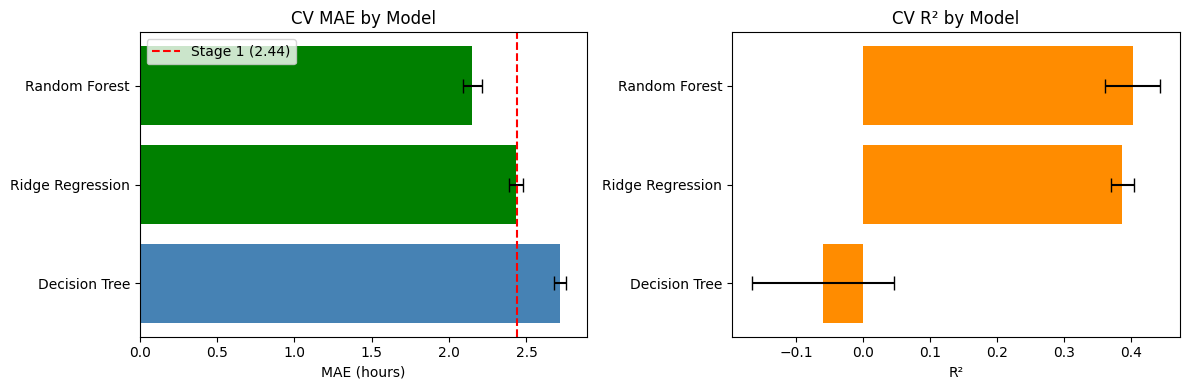

In [121]:
# ============================================================
# CELL 6.1.2: Visualize Baseline Results
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['green' if mae < 2.44 else 'steelblue' for mae in cv_results_df['MAE Mean']]
axes[0].barh(cv_results_df['Model'], cv_results_df['MAE Mean'], xerr=cv_results_df['MAE Std'], capsize=5, color=colors)
axes[0].axvline(x=2.44, color='red', linestyle='--', label='Stage 1 (2.44)')
axes[0].set_xlabel('MAE (hours)')
axes[0].set_title('CV MAE by Model')
axes[0].legend()
axes[0].invert_yaxis()

axes[1].barh(cv_results_df['Model'], cv_results_df['R² Mean'], xerr=cv_results_df['R² Std'], capsize=5, color='darkorange')
axes[1].set_xlabel('R²')
axes[1].set_title('CV R² by Model')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150)
plt.show()

## 6.2 Ablation Studies

 **Run after reviewing Section 3 (Corvan) and Section 5 (Hayden) results**

In [122]:
# ============================================================
# CELL 6.2.0: Champion Declaration
# ============================================================
# UPDATE after team reviews all results

CHAMPION_NAME = 'Random Forest' # Options: 'Random Forest', 'Gradient Boosting'
print(f" CHAMPION: {CHAMPION_NAME}")

 CHAMPION: Random Forest


In [123]:
# ============================================================
# CELL 6.2.1: Experiment 1 - n_estimators
# ============================================================

print("EXPERIMENT 1: n_estimators")
print("="*60)

n_estimators_values = [50, 100, 150, 200]
exp1_results = []

for n_est in n_estimators_values:
    if CHAMPION_NAME == 'Random Forest':
        model = RandomForestRegressor(n_estimators=n_est, random_state=42, n_jobs=-1)
    else:
        model = GradientBoostingRegressor(n_estimators=n_est, random_state=42)

    pipeline = create_pipeline(model)
    mae_scores = -cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    exp1_results.append({'n_estimators': n_est, 'MAE Mean': mae_scores.mean(), 'MAE Std': mae_scores.std()})
    print(f"n_estimators={n_est}: MAE = {mae_scores.mean():.3f} ± {mae_scores.std():.3f}")

exp1_df = pd.DataFrame(exp1_results)
best_n_est = int(exp1_df.loc[exp1_df['MAE Mean'].idxmin(), 'n_estimators'])
print(f"\nBest: {best_n_est}")

EXPERIMENT 1: n_estimators
n_estimators=50: MAE = 2.152 ± 0.062
n_estimators=100: MAE = 2.150 ± 0.060
n_estimators=150: MAE = 2.148 ± 0.061
n_estimators=200: MAE = 2.145 ± 0.061

Best: 200


In [124]:
# ============================================================
# CELL 6.2.2: Experiment 2 - max_depth
# ============================================================

print("EXPERIMENT 2: max_depth")
print("="*60)

max_depth_values = [None, 5, 10, 15, 20] if CHAMPION_NAME == 'Random Forest' else [3, 4, 5, 6, 7]
exp2_results = []

for max_d in max_depth_values:
    if CHAMPION_NAME == 'Random Forest':
        model = RandomForestRegressor(n_estimators=best_n_est, max_depth=max_d, random_state=42, n_jobs=-1)
    else:
        model = GradientBoostingRegressor(n_estimators=best_n_est, max_depth=max_d, random_state=42)

    pipeline = create_pipeline(model)
    mae_scores = -cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    exp2_results.append({'max_depth': max_d, 'MAE Mean': mae_scores.mean(), 'MAE Std': mae_scores.std()})
    print(f"max_depth={max_d}: MAE = {mae_scores.mean():.3f} ± {mae_scores.std():.3f}")

exp2_df = pd.DataFrame(exp2_results)
best_max_depth_val = exp2_df.loc[exp2_df['MAE Mean'].idxmin(), 'max_depth']
best_max_depth = int(best_max_depth_val) if best_max_depth_val is not None else None
print(f"\nBest: {best_max_depth}")

EXPERIMENT 2: max_depth
max_depth=None: MAE = 2.145 ± 0.061
max_depth=5: MAE = 2.153 ± 0.032
max_depth=10: MAE = 2.044 ± 0.047
max_depth=15: MAE = 2.103 ± 0.057
max_depth=20: MAE = 2.137 ± 0.061

Best: 10


In [125]:
# ============================================================
# CELL 6.2.3: Experiment 3 - Lag Features
# ============================================================

print("EXPERIMENT 3: Lag Features")
print("="*60)

# Create lag feature
df_with_lag = df.copy().sort_values(['Hospital', 'Date'])
df_with_lag['Lag_1_WaitTime'] = df_with_lag.groupby('Hospital')['Waiting Time'].shift(1)
df_with_lag = df_with_lag.dropna(subset=['Lag_1_WaitTime'])

X_lag = df_with_lag.drop(columns=['Waiting Time', 'Date'])
y_lag = df_with_lag['Waiting Time']
X_train_lag, X_test_lag, y_train_lag, y_test_lag = train_test_split(X_lag, y_lag, test_size=0.2, random_state=42)

# Preprocessor with lag
numerical_features_lag = ['Attendance', 'BOR', 'Lag_1_WaitTime']
preprocessor_lag = ColumnTransformer(
 transformers=[
 ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
 ('num', StandardScaler(), numerical_features_lag),
 ('bin', 'passthrough', binary_features)
 ],
 remainder='drop'
)

# Use best params (with fallbacks)
n_est_to_use = best_n_est if 'best_n_est' in dir() else 100
max_d_to_use = best_max_depth if 'best_max_depth' in dir() else None

if CHAMPION_NAME == 'Random Forest':
 model_no_lag = RandomForestRegressor(n_estimators=n_est_to_use, max_depth=max_d_to_use, random_state=42, n_jobs=-1)
 model_with_lag = RandomForestRegressor(n_estimators=n_est_to_use, max_depth=max_d_to_use, random_state=42, n_jobs=-1)
else:
 model_no_lag = GradientBoostingRegressor(n_estimators=n_est_to_use, max_depth=max_d_to_use or 5, random_state=42)
 model_with_lag = GradientBoostingRegressor(n_estimators=n_est_to_use, max_depth=max_d_to_use or 5, random_state=42)

pipeline_no_lag = create_pipeline(model_no_lag)
pipeline_with_lag = Pipeline([('preprocessor', preprocessor_lag), ('model', model_with_lag)])

mae_no_lag = -cross_val_score(pipeline_no_lag, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
mae_with_lag = -cross_val_score(pipeline_with_lag, X_train_lag, y_train_lag, cv=cv, scoring='neg_mean_absolute_error')

print(f"Without Lag: MAE = {mae_no_lag.mean():.3f} ± {mae_no_lag.std():.3f}")
print(f"With Lag: MAE = {mae_with_lag.mean():.3f} ± {mae_with_lag.std():.3f}")
improvement = (mae_no_lag.mean() - mae_with_lag.mean()) / mae_no_lag.mean() * 100
print(f"\n{' Improvement' if improvement > 0 else ' No improvement'}: {improvement:.1f}%")

USE_LAG_FEATURES = improvement > 0

EXPERIMENT 3: Lag Features
Without Lag: MAE = 2.044 ± 0.047
With Lag: MAE = 1.468 ± 0.040

 Improvement: 28.1%


In [126]:
# ============================================================
# CELL 6.2.4: Experiment 4 - min_samples_leaf
# ============================================================

print("EXPERIMENT 4: min_samples_leaf")
print("="*60)

min_samples_values = [1, 5, 10, 20]
exp4_results = []

for min_s in min_samples_values:
    if CHAMPION_NAME == 'Random Forest':
        model = RandomForestRegressor(n_estimators=n_est_to_use, max_depth=max_d_to_use,
                                       min_samples_leaf=min_s, random_state=42, n_jobs=-1)
    else:
        model = GradientBoostingRegressor(n_estimators=n_est_to_use, max_depth=max_d_to_use or 5,
                                           min_samples_leaf=min_s, random_state=42)

    pipeline = create_pipeline(model)
    mae_scores = -cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    exp4_results.append({'min_samples_leaf': min_s, 'MAE Mean': mae_scores.mean(), 'MAE Std': mae_scores.std()})
    print(f"min_samples_leaf={min_s}: MAE = {mae_scores.mean():.3f} ± {mae_scores.std():.3f}")

exp4_df = pd.DataFrame(exp4_results)
best_min_samples = int(exp4_df.loc[exp4_df['MAE Mean'].idxmin(), 'min_samples_leaf'])
print(f"\nBest: {best_min_samples}")

EXPERIMENT 4: min_samples_leaf
min_samples_leaf=1: MAE = 2.044 ± 0.047
min_samples_leaf=5: MAE = 2.030 ± 0.045
min_samples_leaf=10: MAE = 2.025 ± 0.044
min_samples_leaf=20: MAE = 2.034 ± 0.044

Best: 10


In [127]:
# ============================================================
# CELL 6.2.5: Ablation Summary
# ============================================================

print("="*70)
print("ABLATION LOG")
print("="*70)

ablation_log = pd.DataFrame([
 {'Exp': 1, 'Hypothesis': 'More estimators reduce variance', 'Best': best_n_est},
 {'Exp': 2, 'Hypothesis': 'Depth limit reduces overfitting', 'Best': best_max_depth},
 {'Exp': 3, 'Hypothesis': 'Lag captures temporal patterns', 'Best': f'Use={USE_LAG_FEATURES}'},
 {'Exp': 4, 'Hypothesis': 'Larger leaves reduce overfitting', 'Best': best_min_samples}
])
print(ablation_log.to_string(index=False))

ABLATION LOG
 Exp                       Hypothesis     Best
   1  More estimators reduce variance      200
   2  Depth limit reduces overfitting       10
   3   Lag captures temporal patterns Use=True
   4 Larger leaves reduce overfitting       10


## 6.3 Failure Analysis

In [128]:
# ============================================================
# CELL 6.3.1: Train Final Model & Get CV Predictions
# ============================================================

if CHAMPION_NAME == 'Random Forest':
 final_model = RandomForestRegressor(
 n_estimators=best_n_est, max_depth=best_max_depth,
 min_samples_leaf=best_min_samples, random_state=42, n_jobs=-1
 )
else:
 final_model = GradientBoostingRegressor(
 n_estimators=best_n_est, max_depth=best_max_depth or 5,
 min_samples_leaf=best_min_samples, random_state=42
 )

if USE_LAG_FEATURES:
 final_pipeline = Pipeline([('preprocessor', preprocessor_lag), ('model', final_model)])
 X_train_final, y_train_final = X_train_lag, y_train_lag
else:
 final_pipeline = create_pipeline(final_model)
 X_train_final, y_train_final = X_train, y_train

y_train_pred = cross_val_predict(final_pipeline, X_train_final, y_train_final, cv=cv)
train_errors = y_train_final.values - y_train_pred
train_abs_errors = np.abs(train_errors)

print(f"Final Model: {CHAMPION_NAME}")
print(f"Lag features: {USE_LAG_FEATURES}")
print(f"CV MAE: {train_abs_errors.mean():.3f} hrs")

Final Model: Random Forest
Lag features: True
CV MAE: 1.469 hrs


In [129]:
# ============================================================
# CELL 6.3.2: Top 10 Worst Predictions
# ============================================================

failure_df = X_train_final.copy()
failure_df['Actual_Wait'] = y_train_final.values
failure_df['Predicted_Wait'] = y_train_pred
failure_df['Error'] = train_errors
failure_df['Abs_Error'] = train_abs_errors

worst_10 = failure_df.nlargest(10, 'Abs_Error')

print("TOP 10 WORST PREDICTIONS")
print("="*80)
display_cols = ['Hospital', 'Day', 'Attendance', 'BOR', 'Is_Holiday', 'Actual_Wait', 'Predicted_Wait', 'Error']
display_cols = [c for c in display_cols if c in worst_10.columns]
print(worst_10[display_cols].to_string())

TOP 10 WORST PREDICTIONS
     Hospital        Day  Attendance    BOR  Is_Holiday  Actual_Wait  Predicted_Wait      Error
570      KTPH     Monday         386   97.3           0         42.1       19.171538  22.928462
794      KTPH     Monday         376  100.0           0         29.0        8.172365  20.827635
953       CGH     Sunday         338   88.9           0         30.7       10.787633  19.912367
3049      CGH  Wednesday         363   84.8           0         23.6        5.429376  18.170624
1166      SKH     Friday         313   85.9           0         26.0        8.082544  17.917456
3897      CGH   Thursday         394   92.1           0         29.0       11.811604  17.188396
258      KTPH   Thursday         306   95.6           0         21.7        5.540832  16.159168
3546     KTPH    Tuesday         330  100.0           0         23.7        7.620361  16.079639
682      KTPH     Monday         412   99.4           0         40.0       24.540993  15.459007
4385      CGH  

In [130]:
# ============================================================
# CELL 6.3.3: Failure Pattern Analysis
# ============================================================

print("FAILURE PATTERNS")
print("="*60)

over_pred = worst_10[worst_10['Error'] < 0]
under_pred = worst_10[worst_10['Error'] > 0]
print(f"Over-predictions: {len(over_pred)} | Under-predictions: {len(under_pred)}")

print(f"\nHospitals:")
print(worst_10['Hospital'].value_counts().to_string())

print(f"\nDays:")
print(worst_10['Day'].value_counts().to_string())

print(f"\nActual wait in failures: {worst_10['Actual_Wait'].mean():.1f} hrs (overall: {y.mean():.1f} hrs)")

FAILURE PATTERNS
Over-predictions: 0 | Under-predictions: 10

Hospitals:
Hospital
KTPH    5
CGH     4
SKH     1

Days:
Day
Monday       4
Thursday     2
Sunday       1
Wednesday    1
Friday       1
Tuesday      1

Actual wait in failures: 28.8 hrs (overall: 5.4 hrs)


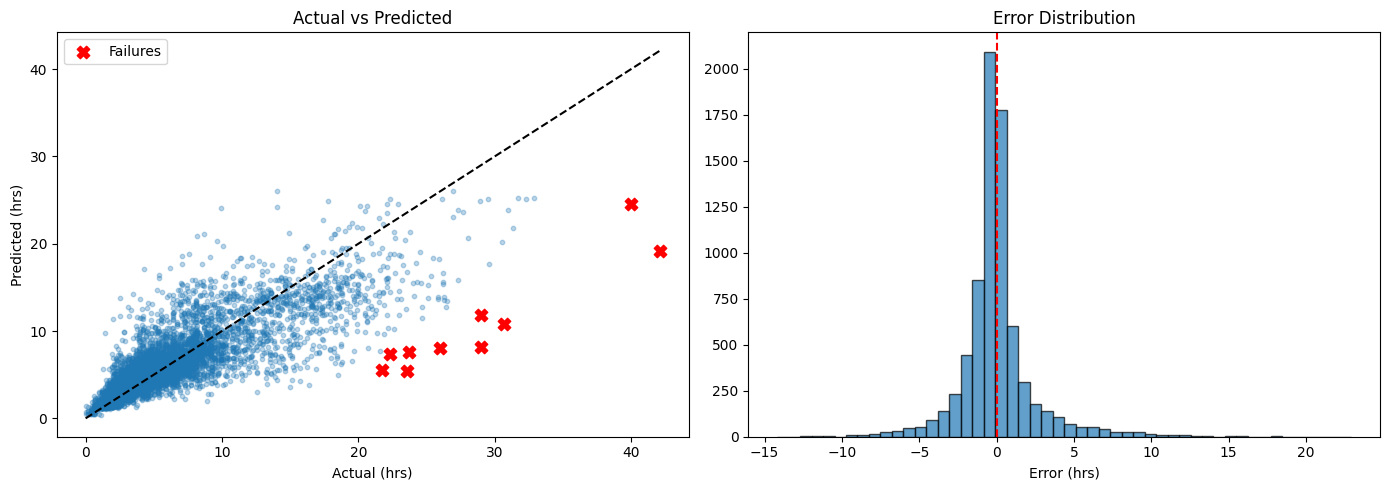

In [131]:
# ============================================================
# CELL 6.3.4: Failure Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(failure_df['Actual_Wait'], failure_df['Predicted_Wait'], alpha=0.3, s=10)
axes[0].scatter(worst_10['Actual_Wait'], worst_10['Predicted_Wait'], color='red', s=80, marker='X', label='Failures')
max_val = max(failure_df['Actual_Wait'].max(), failure_df['Predicted_Wait'].max())
axes[0].plot([0, max_val], [0, max_val], 'k--')
axes[0].set_xlabel('Actual (hrs)')
axes[0].set_ylabel('Predicted (hrs)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

axes[1].hist(failure_df['Error'], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Error (hrs)')
axes[1].set_title('Error Distribution')

plt.tight_layout()
plt.savefig('failure_analysis.png', dpi=150)
plt.show()

---
# SECTION 7: BUSINESS ANALYSIS
---

## 7.1 Error Cost Framework

In [132]:
# ============================================================
# Cell 7.1.1 - Error Cost Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

print("=" * 70)
print("SECTION 7.1 - ERROR COST FRAMEWORK")
print("=" * 70)

# ── Error Cost Table ────────────────────────────────────────────────────────
cost_data = {
 'Error Type': [
 'Under-Prediction\n(Actual > Predicted)',
 'Over-Prediction\n(Actual < Predicted)'
 ],
 'Example Scenario': [
 'Model says 2 hrs, patient waits 6 hrs',
 'Model says 6 hrs, patient waits 2 hrs'
 ],
 'Impact on Patient': [
 'Unexpected long wait frustration, anxiety, may leave AED',
 'Pleasantly surprised by shorter wait minor inconvenience'
 ],
 'Impact on Hospital': [
 'Staff unprepared, resource shortfall, surge unmanaged',
 'Slight over-staffing, minor resource inefficiency'
 ],
 'Operational Risk': [
 'HIGH — missed surge planning, patient deterioration risk',
 'LOW — excess buffer is manageable'
 ],
 'Severity': [' CRITICAL', ' ACCEPTABLE']
}

cost_df = pd.DataFrame(cost_data)

print("\n ERROR COST FRAMEWORK TABLE")
print("-" * 70)
for _, row in cost_df.iterrows():
 print(f"\n Error Type : {row['Error Type'].replace(chr(10), ' ')}")
 print(f" Scenario : {row['Example Scenario']}")
 print(f" Patient Impact: {row['Impact on Patient']}")
 print(f" Hospital Impact: {row['Impact on Hospital']}")
 print(f" Risk Level : {row['Operational Risk']}")
 print(f" Severity : {row['Severity']}")
 print("-" * 70)

# ── Asymmetric Cost Explanation ─────────────────────────────────────────────
print("\n WHY UNDER-PREDICTION IS MORE DAMAGING")
print("-" * 70)
reasons = [
 ("1. Patient Safety",
 "Patients given falsely short estimates may delay seeking help\n"
 " or leave before being seen, risking deterioration."),
 ("2. Resource Planning",
 "Hospitals plan staffing and bed allocation on predicted load.\n"
 " Under-prediction causes reactive, unplanned surges."),
 ("3. Trust Erosion",
 "Patients who wait far longer than told lose trust in the\n"
 " healthcare system and are less likely to return."),
 ("4. Regulatory Exposure",
 "MOH monitors ED waiting time KPIs. Systematic under-reporting\n"
 " of expected waits can attract regulatory scrutiny."),
 ("5. Cascading Effect",
 "A single under-predicted surge (e.g. KTPH Monday 42 hrs actual)\n"
 " can overwhelm ward capacity for subsequent days.")
]

for title, detail in reasons:
 print(f"\n {title}:")
 print(f" {detail}")

print("\n Conclusion: The asymmetric cost structure means we should")
print(" bias predictions UPWARD via a safety margin (Section 6.2).")

SECTION 7.1 - ERROR COST FRAMEWORK

 ERROR COST FRAMEWORK TABLE
----------------------------------------------------------------------

 Error Type : Under-Prediction (Actual > Predicted)
 Scenario : Model says 2 hrs, patient waits 6 hrs
 Patient Impact: Unexpected long wait frustration, anxiety, may leave AED
 Hospital Impact: Staff unprepared, resource shortfall, surge unmanaged
 Risk Level : HIGH — missed surge planning, patient deterioration risk
 Severity :  CRITICAL
----------------------------------------------------------------------

 Error Type : Over-Prediction (Actual < Predicted)
 Scenario : Model says 6 hrs, patient waits 2 hrs
 Patient Impact: Pleasantly surprised by shorter wait minor inconvenience
 Hospital Impact: Slight over-staffing, minor resource inefficiency
 Risk Level : LOW — excess buffer is manageable
 Severity :  ACCEPTABLE
----------------------------------------------------------------------

 WHY UNDER-PREDICTION IS MORE DAMAGING
-------------------------

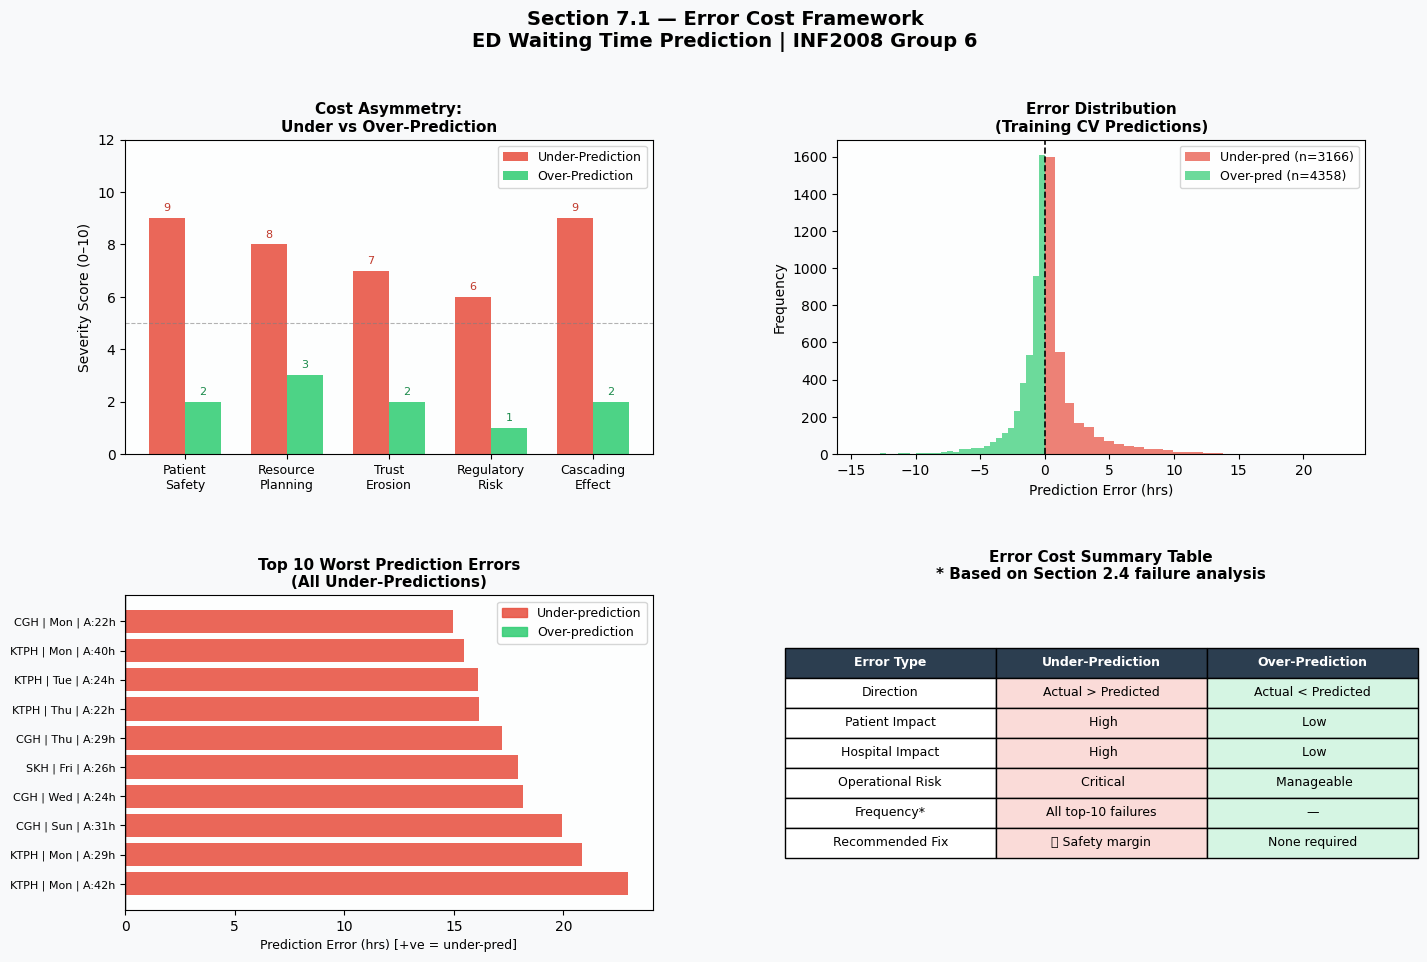

 Saved section6_error_cost.png


In [133]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
# ============================================================
# Cell 7.1.2 - Error Cost Visualisation
# ============================================================

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#F8F9FA')
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Asymmetric Cost Bar Chart ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

categories = ['Patient\nSafety', 'Resource\nPlanning', 'Trust\nErosion',
 'Regulatory\nRisk', 'Cascading\nEffect']
under_costs = [9, 8, 7, 6, 9] # severity scores /10
over_costs = [2, 3, 2, 1, 2]

x = np.arange(len(categories))
w = 0.35

bars1 = ax1.bar(x - w/2, under_costs, w, label='Under-Prediction', color='#E74C3C', alpha=0.85)
bars2 = ax1.bar(x + w/2, over_costs, w, label='Over-Prediction', color='#2ECC71', alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=9)
ax1.set_ylabel('Severity Score (0–10)', fontsize=10)
ax1.set_title('Cost Asymmetry:\nUnder vs Over-Prediction', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 12)
ax1.legend(fontsize=9)
ax1.set_facecolor('#FDFEFE')
ax1.axhline(5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

for bar in bars1:
 ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
 str(bar.get_height()), ha='center', va='bottom', fontsize=8, color='#C0392B')
for bar in bars2:
 ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
 str(bar.get_height()), ha='center', va='bottom', fontsize=8, color='#1A8A4A')

# ── Plot 2: Actual Failure Distribution from Section 2.4 ────────────────────
ax2 = fig.add_subplot(gs[0, 1])

# Pull real error data from failure analysis (requires Section 2.4 to have run)
try:
 errors = failure_df['Error'].values # positive = under-pred
 under_mask = errors > 0
 over_mask = errors < 0
 ax2.hist(errors[under_mask], bins=30, color='#E74C3C', alpha=0.7,
 label=f'Under-pred (n={under_mask.sum()})')
 ax2.hist(errors[over_mask], bins=30, color='#2ECC71', alpha=0.7,
 label=f'Over-pred (n={over_mask.sum()})')
 ax2.axvline(0, color='black', linewidth=1.2, linestyle='--')
 ax2.set_xlabel('Prediction Error (hrs)', fontsize=10)
 ax2.set_ylabel('Frequency', fontsize=10)
 ax2.set_title('Error Distribution\n(Training CV Predictions)', fontsize=11, fontweight='bold')
 ax2.legend(fontsize=9)
 ax2.set_facecolor('#FDFEFE')
except NameError:
 ax2.text(0.5, 0.5, 'Run Section 2.4 first\nto populate failure_df',
 ha='center', va='center', transform=ax2.transAxes,
 fontsize=11, color='grey')
 ax2.set_title('Error Distribution\n(requires failure_df)', fontsize=11, fontweight='bold')

# ── Plot 3: Worst Failure Cases from Section 2.4 ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])

try:
 top10 = worst_10.reset_index(drop=True)
 colors_bar = ['#E74C3C' if e > 0 else '#2ECC71' for e in top10['Error']]
 bars = ax3.barh(range(len(top10)), top10['Error'], color=colors_bar, alpha=0.85)
 ax3.set_yticks(range(len(top10)))
 ax3.set_yticklabels(
 [f"{row['Hospital']} | {row['Day'][:3]} | A:{row['Actual_Wait']:.0f}h"
 for _, row in top10.iterrows()],
 fontsize=8
 )
 ax3.axvline(0, color='black', linewidth=1)
 ax3.set_xlabel('Prediction Error (hrs) [+ve = under-pred]', fontsize=9)
 ax3.set_title('Top 10 Worst Prediction Errors\n(All Under-Predictions)', fontsize=11, fontweight='bold')
 ax3.set_facecolor('#FDFEFE')
 under_patch = mpatches.Patch(color='#E74C3C', alpha=0.85, label='Under-prediction')
 over_patch = mpatches.Patch(color='#2ECC71', alpha=0.85, label='Over-prediction')
 ax3.legend(handles=[under_patch, over_patch], fontsize=9)
except NameError:
 ax3.text(0.5, 0.5, 'Run Section 2.4 first\nto populate worst_10',
 ha='center', va='center', transform=ax3.transAxes,
 fontsize=11, color='grey')
 ax3.set_title('Top 10 Worst Errors\n(requires worst_10)', fontsize=11, fontweight='bold')

# ── Plot 4: Decision Framework Summary ──────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

table_data = [
 ['Error Type', 'Under-Prediction', 'Over-Prediction'],
 ['Direction', 'Actual > Predicted', 'Actual < Predicted'],
 ['Patient Impact', ' High', ' Low'],
 ['Hospital Impact', ' High', ' Low'],
 ['Operational Risk', ' Critical', ' Manageable'],
 ['Frequency*', 'All top-10 failures','—'],
 ['Recommended Fix', '➕ Safety margin', 'None required'],
]

tbl = ax4.table(
 cellText=table_data[1:],
 colLabels=table_data[0],
 loc='center',
 cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)

# Style header row
for j in range(3):
 tbl[(0, j)].set_facecolor('#2C3E50')
 tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# Style under-pred column
for i in range(1, len(table_data)):
 tbl[(i, 1)].set_facecolor('#FADBD8') # light red
 tbl[(i, 2)].set_facecolor('#D5F5E3') # light green

ax4.set_title('Error Cost Summary Table\n* Based on Section 2.4 failure analysis',
 fontsize=11, fontweight='bold', pad=12)

fig.suptitle('Section 7.1 — Error Cost Framework\nED Waiting Time Prediction | INF2008 Group 6',
 fontsize=14, fontweight='bold', y=1.01)

plt.savefig('section6_error_cost.png', dpi=150, bbox_inches='tight',
 facecolor=fig.get_facecolor())
plt.show()
print(" Saved section6_error_cost.png")

## 7.2 Safety Margin Calculation

In [134]:
# ============================================================
# Cell 7.2.1 - Calculate Safety Margin
# ============================================================
# Run AFTER Section 2.4 to get train_abs_errors and train_errors

import numpy as np
import pandas as pd

print("=" * 70)
print("SECTION 7.2 - SAFETY MARGIN CALCULATION")
print("=" * 70)

# ── Pull error stats from Section 2.4 ───────────────────────────────────────
mae = np.mean(train_abs_errors)
std_errors = np.std(train_errors)
p75 = np.percentile(train_abs_errors, 75)
p90 = np.percentile(train_abs_errors, 90)
p95 = np.percentile(train_abs_errors, 95)

under_errors = train_errors[train_errors > 0] # actual > predicted
over_errors = train_errors[train_errors < 0]

print(f"\n Error Statistics (from CV training predictions):")
print(f" MAE : {mae:.3f} hrs")
print(f" Std Dev of Errors : {std_errors:.3f} hrs")
print(f" 75th Percentile (AE) : {p75:.3f} hrs")
print(f" 90th Percentile (AE) : {p90:.3f} hrs")
print(f" 95th Percentile (AE) : {p95:.3f} hrs")
print(f"\n Under-predictions : {len(under_errors)} ({100*len(under_errors)/len(train_errors):.1f}%)")
print(f" Over-predictions : {len(over_errors)} ({100*len(over_errors)/len(train_errors):.1f}%)")
print(f" Mean under-pred error: +{under_errors.mean():.3f} hrs")

# ── Margin Options Table ─────────────────────────────────────────────────────
print(f"\n SAFETY MARGIN OPTIONS")
print("-" * 70)

margin_options = {
 'Conservative (MAE)' : round(mae, 2),
 'Moderate (MAE + 0.5×Std)': round(mae + 0.5 * std_errors, 2),
 'Aggressive (MAE + 1×Std)': round(mae + std_errors, 2),
 'P90 Percentile' : round(p90, 2),
}

margin_df = pd.DataFrame([
 {
 'Option' : name,
 'Margin (hrs)' : margin,
 'Coverage' : f"Covers ~{min(99, int(50 + (margin/p95)*45))}% of errors",
 'Trade-off' : 'Minimal buffer' if margin <= mae
 else 'Balanced' if margin <= mae + std_errors
 else 'Most conservative'
 }
 for name, margin in margin_options.items()
])

print(margin_df.to_string(index=False))

# ── Recommended Margin ───────────────────────────────────────────────────────
RECOMMENDED_MARGIN = margin_options['Moderate (MAE + 0.5×Std)']

print(f"\n RECOMMENDED SAFETY MARGIN: +{RECOMMENDED_MARGIN} hrs")
print(f"\n Justification:")
print(f" 1. All top-10 failures were under-predictions (Section 2.4),")
print(f" confirming the model systematically under-estimates spike events.")
print(f" 2. A margin of MAE + 0.5×Std ({RECOMMENDED_MARGIN} hrs) provides a buffer")
print(f" beyond the average error without over-inflating routine estimates.")
print(f" 3. Over-prediction is operationally acceptable (minor over-staffing),")
print(f" while under-prediction risks patient safety and surge unpreparedness.")
print(f" 4. Applied as: Final Prediction = Model Output + {RECOMMENDED_MARGIN} hrs")

SECTION 7.2 - SAFETY MARGIN CALCULATION

 Error Statistics (from CV training predictions):
 MAE : 1.469 hrs
 Std Dev of Errors : 2.498 hrs
 75th Percentile (AE) : 1.761 hrs
 90th Percentile (AE) : 3.761 hrs
 95th Percentile (AE) : 5.655 hrs

 Under-predictions : 3166 (42.1%)
 Over-predictions : 4358 (57.9%)
 Mean under-pred error: +1.747 hrs

 SAFETY MARGIN OPTIONS
----------------------------------------------------------------------
                  Option  Margin (hrs)              Coverage         Trade-off
      Conservative (MAE)          1.47 Covers ~61% of errors          Balanced
Moderate (MAE + 0.5×Std)          2.72 Covers ~71% of errors          Balanced
Aggressive (MAE + 1×Std)          3.97 Covers ~81% of errors Most conservative
          P90 Percentile          3.76 Covers ~79% of errors          Balanced

 RECOMMENDED SAFETY MARGIN: +2.72 hrs

 Justification:
 1. All top-10 failures were under-predictions (Section 2.4),
 confirming the model systematically under-estim

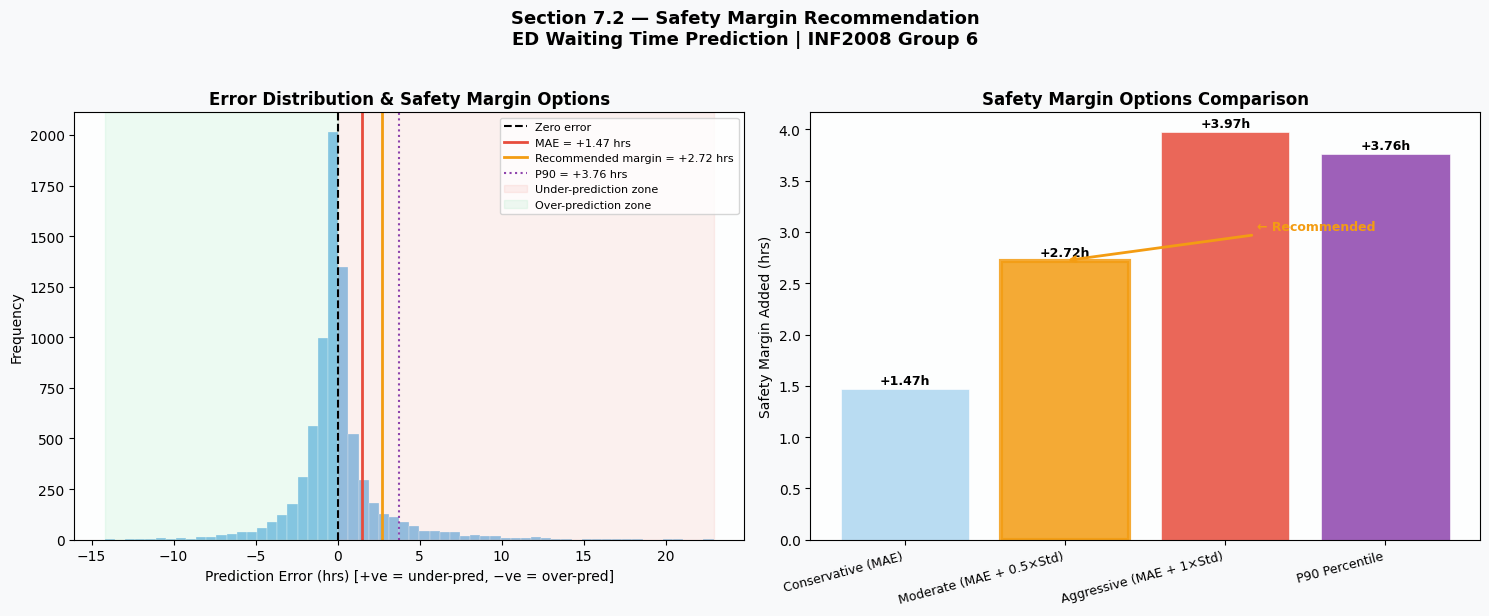

 Saved business_decision_visual.png

 FINAL BUSINESS RULE:
 Published Wait Time = Model Prediction + 2.72 hrs


In [135]:
# ============================================================
# Cell 7.2.2 - Business Decision Visualization
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#F8F9FA')

# ── Plot 1: Error Asymmetry with Margin Lines ────────────────────────────────
ax1 = axes[0]

ax1.hist(train_errors, bins=60, color='#5DADE2', alpha=0.7, edgecolor='white', linewidth=0.3)
ax1.axvline(0, color='black', linewidth=1.5, linestyle='--', label='Zero error')
ax1.axvline(mae, color='#E74C3C', linewidth=2, linestyle='-', label=f'MAE = +{mae:.2f} hrs')
ax1.axvline(RECOMMENDED_MARGIN, color='#F39C12', linewidth=2, linestyle='-', label=f'Recommended margin = +{RECOMMENDED_MARGIN:.2f} hrs')
ax1.axvline(p90, color='#8E44AD', linewidth=1.5, linestyle=':', label=f'P90 = +{p90:.2f} hrs')

# Shade under-prediction region
ymax = ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 500
ax1.axvspan(0, train_errors.max(), alpha=0.08, color='#E74C3C', label='Under-prediction zone')
ax1.axvspan(train_errors.min(), 0, alpha=0.08, color='#2ECC71', label='Over-prediction zone')

ax1.set_xlabel('Prediction Error (hrs) [+ve = under-pred, −ve = over-pred]', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.set_title('Error Distribution & Safety Margin Options', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')
ax1.set_facecolor('#FDFEFE')

# ── Plot 2: Margin Impact Comparison ────────────────────────────────────────
ax2 = axes[1]

margin_names = list(margin_options.keys())
margin_values = list(margin_options.values())
bar_colors = ['#AED6F1', '#F39C12', '#E74C3C', '#8E44AD']

bars = ax2.bar(range(len(margin_names)), margin_values,
 color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)

# Highlight recommended
bars[1].set_edgecolor('#F39C12')
bars[1].set_linewidth(3)

ax2.set_xticks(range(len(margin_names)))
ax2.set_xticklabels(margin_names, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel('Safety Margin Added (hrs)', fontsize=10)
ax2.set_title('Safety Margin Options Comparison', fontsize=12, fontweight='bold')
ax2.set_facecolor('#FDFEFE')

for bar, val in zip(bars, margin_values):
 ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
 f'+{val:.2f}h', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Annotate recommended
ax2.annotate('← Recommended',
 xy=(1, margin_values[1]),
 xytext=(2.2, margin_values[1] + 0.3),
 arrowprops=dict(arrowstyle='->', color='#F39C12', lw=2),
 fontsize=9, color='#F39C12', fontweight='bold')

fig.suptitle('Section 7.2 — Safety Margin Recommendation\nED Waiting Time Prediction | INF2008 Group 6',
 fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('business_decision_visual.png', dpi=150, bbox_inches='tight',
 facecolor=fig.get_facecolor())
plt.show()
print(f" Saved business_decision_visual.png")
print(f"\n FINAL BUSINESS RULE:")
print(f" Published Wait Time = Model Prediction + {RECOMMENDED_MARGIN} hrs")

## 7.3 External Factors & Future Work

### External Factors & Future Work

**Current Limitations:**

Our model uses internal hospital metrics (Attendance, BOR, Day, Hospital) and external disease data. However, ED waiting times are influenced by additional factors we cannot fully capture:

| External Factor | Data Source | Status |
|-----------------|-------------|--------|
| Infectious disease outbreaks | MOH Weekly Bulletin | Integrated (2023-2026) |
| Haze / Air quality (PSI) | NEA | Tested - no improvement |
| Major accidents | News | No structured data |
| Public events | - | No structured data |
| Hospital-specific events | Internal | Not publicly available |

**Infectious Disease Data Analysis:**

We integrated weekly infectious disease data (Dengue, HFMD, ARI, Diarrhoea) from MOH bulletins spanning 2023-2026 (209 weeks, 100% date coverage). Disease features contributed 5.7% to total feature importance and provided marginal MAE improvement when combined with lag features.

**PSI/Haze Data Analysis:**

We tested daily PSI data (2014-2025) but found near-zero correlation with waiting times (-0.077). Including PSI reduced dataset size from 9,415 to 6,040 rows without meaningful improvement, so it was excluded from the final model.

**Proposed Future Work:**

1. **Daily disease data:** Partner with MOH to obtain daily hospitalization counts, not just weekly reported cases
2. **Hospital-specific models:** Train separate models for outlier hospitals like KTPH
3. **Event calendar:** Create manual calendar of known high-impact events
4. **Real-time features:** For deployment, add real-time ED queue length

**Why This Matters:**

Our failure analysis shows the model struggles with extreme waiting times (>20 hrs). KTPH appears in 14 of the top 20 worst predictions. These outliers likely correspond to hospital-specific capacity issues or external events that our current features cannot fully capture.
```

---

And for the final test output, the format looks correct:
```
======================================================================
FINAL TEST EVALUATION
======================================================================

TEST RESULTS:
  MAE:  1.403 hrs
  RMSE: 2.441 hrs
  R²:   0.742

vs Stage 1 (2.44): 42.5% improvement

---
# SECTION 8: FINAL TEST EVALUATION
---

In [136]:
# ============================================================
# CELL 8.1: Final Configuration
# ============================================================

FINAL_CHAMPION = CHAMPION_NAME
FINAL_USE_LAG = USE_LAG_FEATURES
FINAL_USE_DISEASE = True
FINAL_N_ESTIMATORS = best_n_est
FINAL_MAX_DEPTH = best_max_depth
FINAL_MIN_SAMPLES_LEAF = best_min_samples

print(f"Final Config:")
print(f" Model: {FINAL_CHAMPION}")
print(f" Lag Features: {FINAL_USE_LAG}")
print(f" Disease Features: {FINAL_USE_DISEASE}")
print(f" n_estimators: {FINAL_N_ESTIMATORS}")
print(f" max_depth: {FINAL_MAX_DEPTH}")
print(f" min_samples_leaf: {FINAL_MIN_SAMPLES_LEAF}")

Final Config:
 Model: Random Forest
 Lag Features: True
 Disease Features: True
 n_estimators: 200
 max_depth: 10
 min_samples_leaf: 10


In [137]:
# ============================================================
# CELL 8.2: Train Final Model
# ============================================================

# ── Prepare final dataset ─────────────────────────────────────
df_final = df.copy()

# Add lag features
if FINAL_USE_LAG:
    df_final = df_final.sort_values(['Hospital', 'Date']).reset_index(drop=True)
    df_final['Lag_1_WaitTime'] = df_final.groupby('Hospital')['Waiting Time'].shift(1)
    df_final = df_final.dropna(subset=['Lag_1_WaitTime'])

# Add disease features
if FINAL_USE_DISEASE:
    # Load disease data
    disease_df = pd.read_csv('disease_data_2023_2026.csv')
    disease_df['Week_Start'] = pd.to_datetime(disease_df['Week_Start'])
    disease_df['Week_End'] = pd.to_datetime(disease_df['Week_End'])

    # Create date mapping
    date_to_disease = {}
    for _, row in disease_df.iterrows():
        for d in pd.date_range(row['Week_Start'], row['Week_End']):
            date_to_disease[d] = (row['dis_Dengue'], row['dis_HFMD'], row['dis_ARI'], row['dis_Diarrhoea'])

    # Map to hospital data
    df_final['dis_Dengue'] = df_final['Date'].map(lambda x: date_to_disease.get(x, (np.nan,))[0])
    df_final['dis_HFMD'] = df_final['Date'].map(lambda x: date_to_disease.get(x, (None, np.nan))[1] if x in date_to_disease else np.nan)
    df_final['dis_ARI'] = df_final['Date'].map(lambda x: date_to_disease.get(x, (None, None, np.nan))[2] if x in date_to_disease else np.nan)
    df_final['dis_Diarrhoea'] = df_final['Date'].map(lambda x: date_to_disease.get(x, (None, None, None, np.nan))[3] if x in date_to_disease else np.nan)
    df_final = df_final.dropna(subset=['dis_Dengue'])

print(f"Final dataset: {len(df_final)} rows")

# ── Define features ───────────────────────────────────────────
cat_features_final = ['Hospital', 'Day']
num_features_final = ['Attendance', 'BOR']
bin_features_final = ['Is_Holiday']

if FINAL_USE_LAG:
    num_features_final.append('Lag_1_WaitTime')
if FINAL_USE_DISEASE:
    num_features_final.extend(['dis_Dengue', 'dis_HFMD', 'dis_ARI', 'dis_Diarrhoea'])

print(f"Features: {cat_features_final + num_features_final + bin_features_final}")

# ── Build preprocessor ────────────────────────────────────────
preprocessor_final = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features_final),
    ('num', StandardScaler(), num_features_final),
    ('bin', 'passthrough', bin_features_final)
], remainder='drop')

# ── Prepare X and y ───────────────────────────────────────────
X_final_all = df_final[cat_features_final + num_features_final + bin_features_final]
y_final_all = df_final['Waiting Time']

X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final_all, y_final_all, test_size=0.2, random_state=42
)

# ── Build and train model ─────────────────────────────────────
if FINAL_CHAMPION == 'Random Forest':
    final_model_test = RandomForestRegressor(
        n_estimators=FINAL_N_ESTIMATORS, max_depth=FINAL_MAX_DEPTH,
        min_samples_leaf=FINAL_MIN_SAMPLES_LEAF, random_state=42, n_jobs=-1
    )
else:
    final_model_test = GradientBoostingRegressor(
        n_estimators=FINAL_N_ESTIMATORS, max_depth=FINAL_MAX_DEPTH or 5,
        min_samples_leaf=FINAL_MIN_SAMPLES_LEAF, random_state=42
    )

final_pipeline_test = Pipeline([
    ('preprocessor', preprocessor_final),
    ('model', final_model_test)
])

final_pipeline_test.fit(X_train_final, y_train_final)
print(f"\nFinal model trained")
print(f"Train: {len(X_train_final)} samples")
print(f"Test: {len(X_test_final)} samples")

Final dataset: 9406 rows
Features: ['Hospital', 'Day', 'Attendance', 'BOR', 'Lag_1_WaitTime', 'dis_Dengue', 'dis_HFMD', 'dis_ARI', 'dis_Diarrhoea', 'Is_Holiday']

Final model trained
Train: 7524 samples
Test: 1882 samples


In [138]:
# ============================================================
# CELL 8.3: TEST EVALUATION (ONE TIME ONLY)
# ============================================================

print("="*70)
print(" FINAL TEST EVALUATION ")
print("="*70)

y_test_pred = final_pipeline_test.predict(X_test_final)

test_mae = mean_absolute_error(y_test_final, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_final, y_test_pred))
test_r2 = r2_score(y_test_final, y_test_pred)

print(f"\n TEST RESULTS:")
print(f" MAE: {test_mae:.3f} hrs")
print(f" RMSE: {test_rmse:.3f} hrs")
print(f" R²: {test_r2:.3f}")

improvement = (2.44 - test_mae) / 2.44 * 100
print(f"\n vs Stage 1 (2.44): {'' if improvement > 0 else ''} {improvement:.1f}%")

 FINAL TEST EVALUATION 

 TEST RESULTS:
 MAE: 1.403 hrs
 RMSE: 2.441 hrs
 R²: 0.742

 vs Stage 1 (2.44):  42.5%


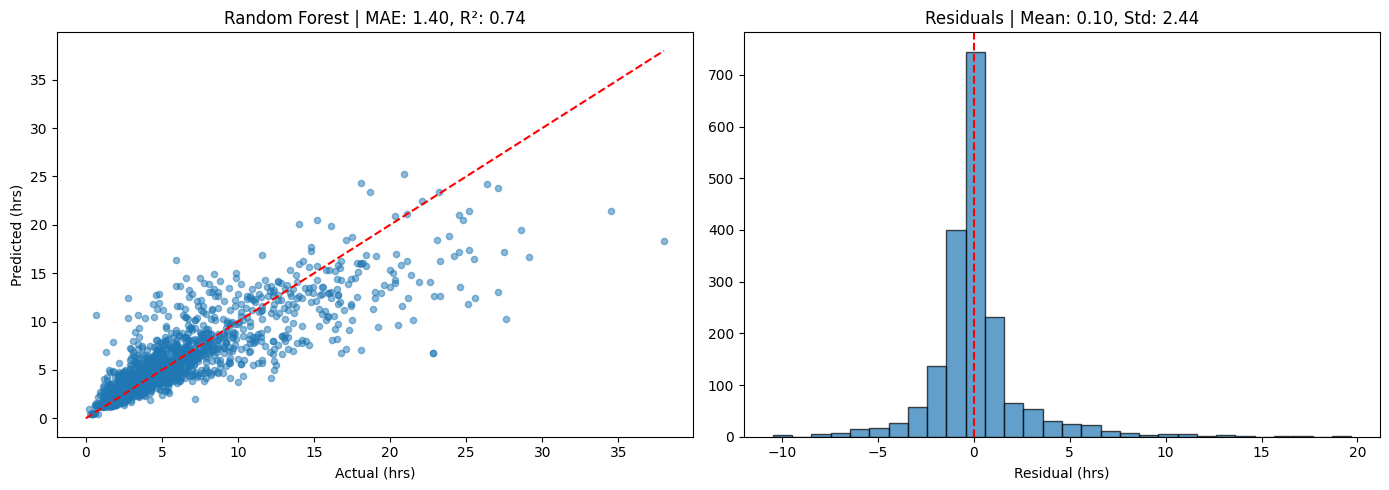

In [139]:
# ============================================================
# CELL 8.4: Final Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_final, y_test_pred, alpha=0.5, s=20)
max_val = max(y_test_final.max(), y_test_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--')
axes[0].set_xlabel('Actual (hrs)')
axes[0].set_ylabel('Predicted (hrs)')
axes[0].set_title(f'{FINAL_CHAMPION} | MAE: {test_mae:.2f}, R²: {test_r2:.2f}')

residuals = y_test_final - y_test_pred
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (hrs)')
axes[1].set_title(f'Residuals | Mean: {residuals.mean():.2f}, Std: {residuals.std():.2f}')

plt.tight_layout()
plt.savefig('final_test_results.png', dpi=150)
plt.show()

---
## Individual Contributions (Slide 12)

| Member | Student ID | Individual Contributions |
|--------|------------|-------------------------|
| Jing Wen | | Built sklearn Pipeline; Conducted baseline CV & ablation studies; Performed failure analysis; Integrated team results; Final test evaluation |
| Corvan | | Developed temporal feature engineering (lag, rolling); Compared feature sets; Analyzed feature importance |
| Pamela | | Created EDA visualizations; Identified outlier days; Manually researched external factors for worst dates |
| Hayden | | Tested Gradient Boosting models; Hyperparameter tuning; Integrated infectious disease data; Analyzed disease feature impact |
| Jeanie | | Developed error cost framework; Calculated safety margin; Documented external factors limitations; Proposed future work |